# GLM Tuning-Variable Analysis (LEC)

Split from `LEC_sploratory_analysis_with_glm_and_population.ipynb`. This notebook fits a per-neuron OLS GLM to ask **which task variables drive LEC firing rates**: place, head direction, goal progress, speed, acceleration, and time/distance from/to the next reward.

Backed by [`glm_analysis_v2.py`](glm_analysis_v2.py) — a sibling of `glm_analysis.py` that uses a **no-intercept, keep-all-bins** parameterization (see method note below).


## Method: per-regressor significance via permutation F-test

For each neuron, we fit a full OLS model

$$y_t = X_t \beta + \varepsilon_t$$

where $X$ is a 127-column design matrix of one-hot encoded task variables (no intercept — see note below). The variables are: **place** (21 bins, one per node), **head direction** (36 ten-degree bins), **goal progress** (10 equal-width bins), and **speed, acceleration, time-from-reward, time-to-reward, distance-from-reward, distance-to-reward** (10 decile bins each).

To test whether a *regressor group* (e.g., all 21 place columns) significantly explains firing-rate variance, we use the classic **nested F-test**:

$$F = \frac{(\mathrm{RSS}_{\mathrm{reduced}} - \mathrm{RSS}_{\mathrm{full}}) / df_{\mathrm{num}}}{\mathrm{RSS}_{\mathrm{full}} / df_{\mathrm{resid}}}$$

where $\mathrm{RSS}_{\mathrm{reduced}}$ is the residual sum of squares for the model with that regressor group's columns dropped, $df_{\mathrm{num}}$ is the number of columns in the group (e.g., 21 for place), and $df_{\mathrm{resid}} = T - n_{\mathrm{params}}$.

The **null distribution of F** is obtained by *circularly shifting the firing rate* by a random offset 100 times, re-fitting both full and reduced models, and computing the F-stat for each shift. A neuron is classified as significantly tuned to a regressor group if its observed F exceeds the **95th percentile** of the permutation distribution.

The **direction of tuning** (+1 / −1) for *ordered* regressors (GP, speed, acceleration, time-/distance-from/to-reward) is the sign of the linear slope fit through the bin-by-bin beta profile — capturing whether the neuron ramps up or down across the variable's range. For *unordered* regressors (place, head direction), we report the sign of the mean beta as a coarse summary.

**Note on the design matrix**: we use **no intercept** and **keep all bins** of each variable (rather than the conventional "drop one reference bin per variable"). This is rank-deficient by 8 (each variable's one-hot block sums to 1, creating linear dependencies between blocks); `np.linalg.lstsq` returns the minimum-norm solution. The F-test is **invariant to this parameterization** — the column space of $X$ is unchanged, so $\mathrm{RSS}_{\mathrm{full}}$ and $\mathrm{RSS}_{\mathrm{reduced}}$ are unchanged. Individual betas now represent absolute firing-rate contributions per bin rather than differences vs a reference bin.


In [6]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import os, pickle
from tqdm import tqdm


In [7]:
Data_folder="../data/processed_data"
figures_folder="../data/figures"
neuron_folder = f"{Data_folder}/neuron_raw_mingyutest"
trialtimes_folder = f"{Data_folder}/trialtimes_raw_mingyutest"
tracking_folder = f"{Data_folder}/processed"


In [8]:
import pickle
import os

# Define the folder where the processed data is saved
processed_data_folder = "../data/processed_data"

# Load the main data dictionary
with open(os.path.join(processed_data_folder, 'data_dic_for_yaren.pkl'), 'rb') as f:
    data_dic = pickle.load(f)

# Load the normalized neurons dictionary
with open(os.path.join(processed_data_folder, 'norm_neurons_dic.pkl'), 'rb') as f:
    norm_neurons_dic = pickle.load(f)

# Load the session indices dictionary
with open(os.path.join(processed_data_folder, 'session_inds_dic.pkl'), 'rb') as f:
    session_inds_dic = pickle.load(f)

# Load the tasks dictionary
with open(os.path.join(processed_data_folder, 'tasks_dic.pkl'), 'rb') as f:
    tasks_dic = pickle.load(f)

print(f"Loaded data dictionaries from {processed_data_folder}")


Loaded data dictionaries from ../data/processed_data


In [9]:
all_files = os.listdir(neuron_folder)
neuron_files = [f for f in all_files if f.startswith('Neuron_raw_') and f.endswith('.npy')]

mouse_recdays_ = []
for f in neuron_files:
    # Remove prefix 'Neuron_raw_' and suffix '.npy'
    stripped_name = f[len('Neuron_raw_'):-len('.npy')]
    # Split by '_' and rejoin all parts except the last one (session number)
    mouse_recday = '_'.join(stripped_name.split('_')[:-1])
    mouse_recdays_.append(mouse_recday)

# Find the unique mouse_recday identifiers
mouse_recdays = np.unique(mouse_recdays_)

# Filter out identifiers containing '_sb'
unique_mouse_recdays = [recday for recday in mouse_recdays if '_sb' not in recday]

print("Unique mouse_recday identifiers (without '_sb'):")
print(unique_mouse_recdays)

# Assign the first unique identifier to mouse_recday for later use
if len(unique_mouse_recdays) > 0:
    mouse_recday = unique_mouse_recdays[0]

mouse_recdays = unique_mouse_recdays


Unique mouse_recday identifiers (without '_sb'):
[np.str_('ah08_20250613_20250615'), np.str_('ah08_20250616_20250617'), np.str_('ah08_20250618_20250619'), np.str_('ah08_20250620_20250623'), np.str_('ah08_20250624_20250625'), np.str_('ah10_20250613_20250615'), np.str_('ah10_20250616_20250617'), np.str_('ah10_20250618_20250619'), np.str_('ah10_20250620_20250623'), np.str_('ah10_20250624_20250625'), np.str_('ly05_20250613_20250615'), np.str_('ly05_20250616_20250617'), np.str_('ly05_20250618_20250619'), np.str_('ly05_20250624_20250625'), np.str_('ly06_20250613_20250615'), np.str_('ly06_20250616_20250617'), np.str_('ly06_20250618_20250619'), np.str_('ly06_20250620_20250623'), np.str_('ly06_20250624_20250625'), np.str_('ly07_20250613_20250615'), np.str_('ly07_20250616_20250617'), np.str_('ly07_20250618_20250619'), np.str_('ly07_20250620_20250623'), np.str_('ly07_20250624_20250625')]


## Fit GLM

In [ ]:
from importlib import reload
import glm_analysis_v2
reload(glm_analysis_v2)

from glm_analysis_v2 import run_glm_analysis

GLM_results, Permutation_results = run_glm_analysis(mouse_recdays, data_dic)

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/24 [1:13:16<28:05:08, 4396.03s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)



# F= (how much worse the reduced model is)  / (how noisy the full model already was)


RSS_full = how badly the full model fits
RSS_reduced = how badly the model fits without goal progress

sign for GP, speed (ordered variables): fit a line through betas, report slope sign

less interpretable for space. not ordered, so just report the mean beta sign (probably get rid of this bit)

## Per-regressor tuning summary

ah08_20250613_20250615: tuning array shape = (151, 9)
ah08_20250616_20250617: tuning array shape = (164, 9)
ah08_20250618_20250619: tuning array shape = (183, 9)
ah08_20250620_20250623: tuning array shape = (108, 9)
ah08_20250624_20250625: tuning array shape = (186, 9)
ah10_20250613_20250615: tuning array shape = (139, 9)
ah10_20250616_20250617: tuning array shape = (154, 9)
ah10_20250618_20250619: tuning array shape = (162, 9)
ah10_20250620_20250623: tuning array shape = (153, 9)
ah10_20250624_20250625: tuning array shape = (164, 9)
ly05_20250613_20250615: tuning array shape = (117, 9)
ly05_20250616_20250617: tuning array shape = (116, 9)
ly05_20250618_20250619: tuning array shape = (91, 9)
ly05_20250624_20250625: tuning array shape = (74, 9)
ly06_20250613_20250615: tuning array shape = (68, 9)
ly06_20250616_20250617: tuning array shape = (79, 9)
ly06_20250618_20250619: tuning array shape = (76, 9)
ly06_20250620_20250623: tuning array shape = (67, 9)
ly06_20250624_20250625: tuning arr

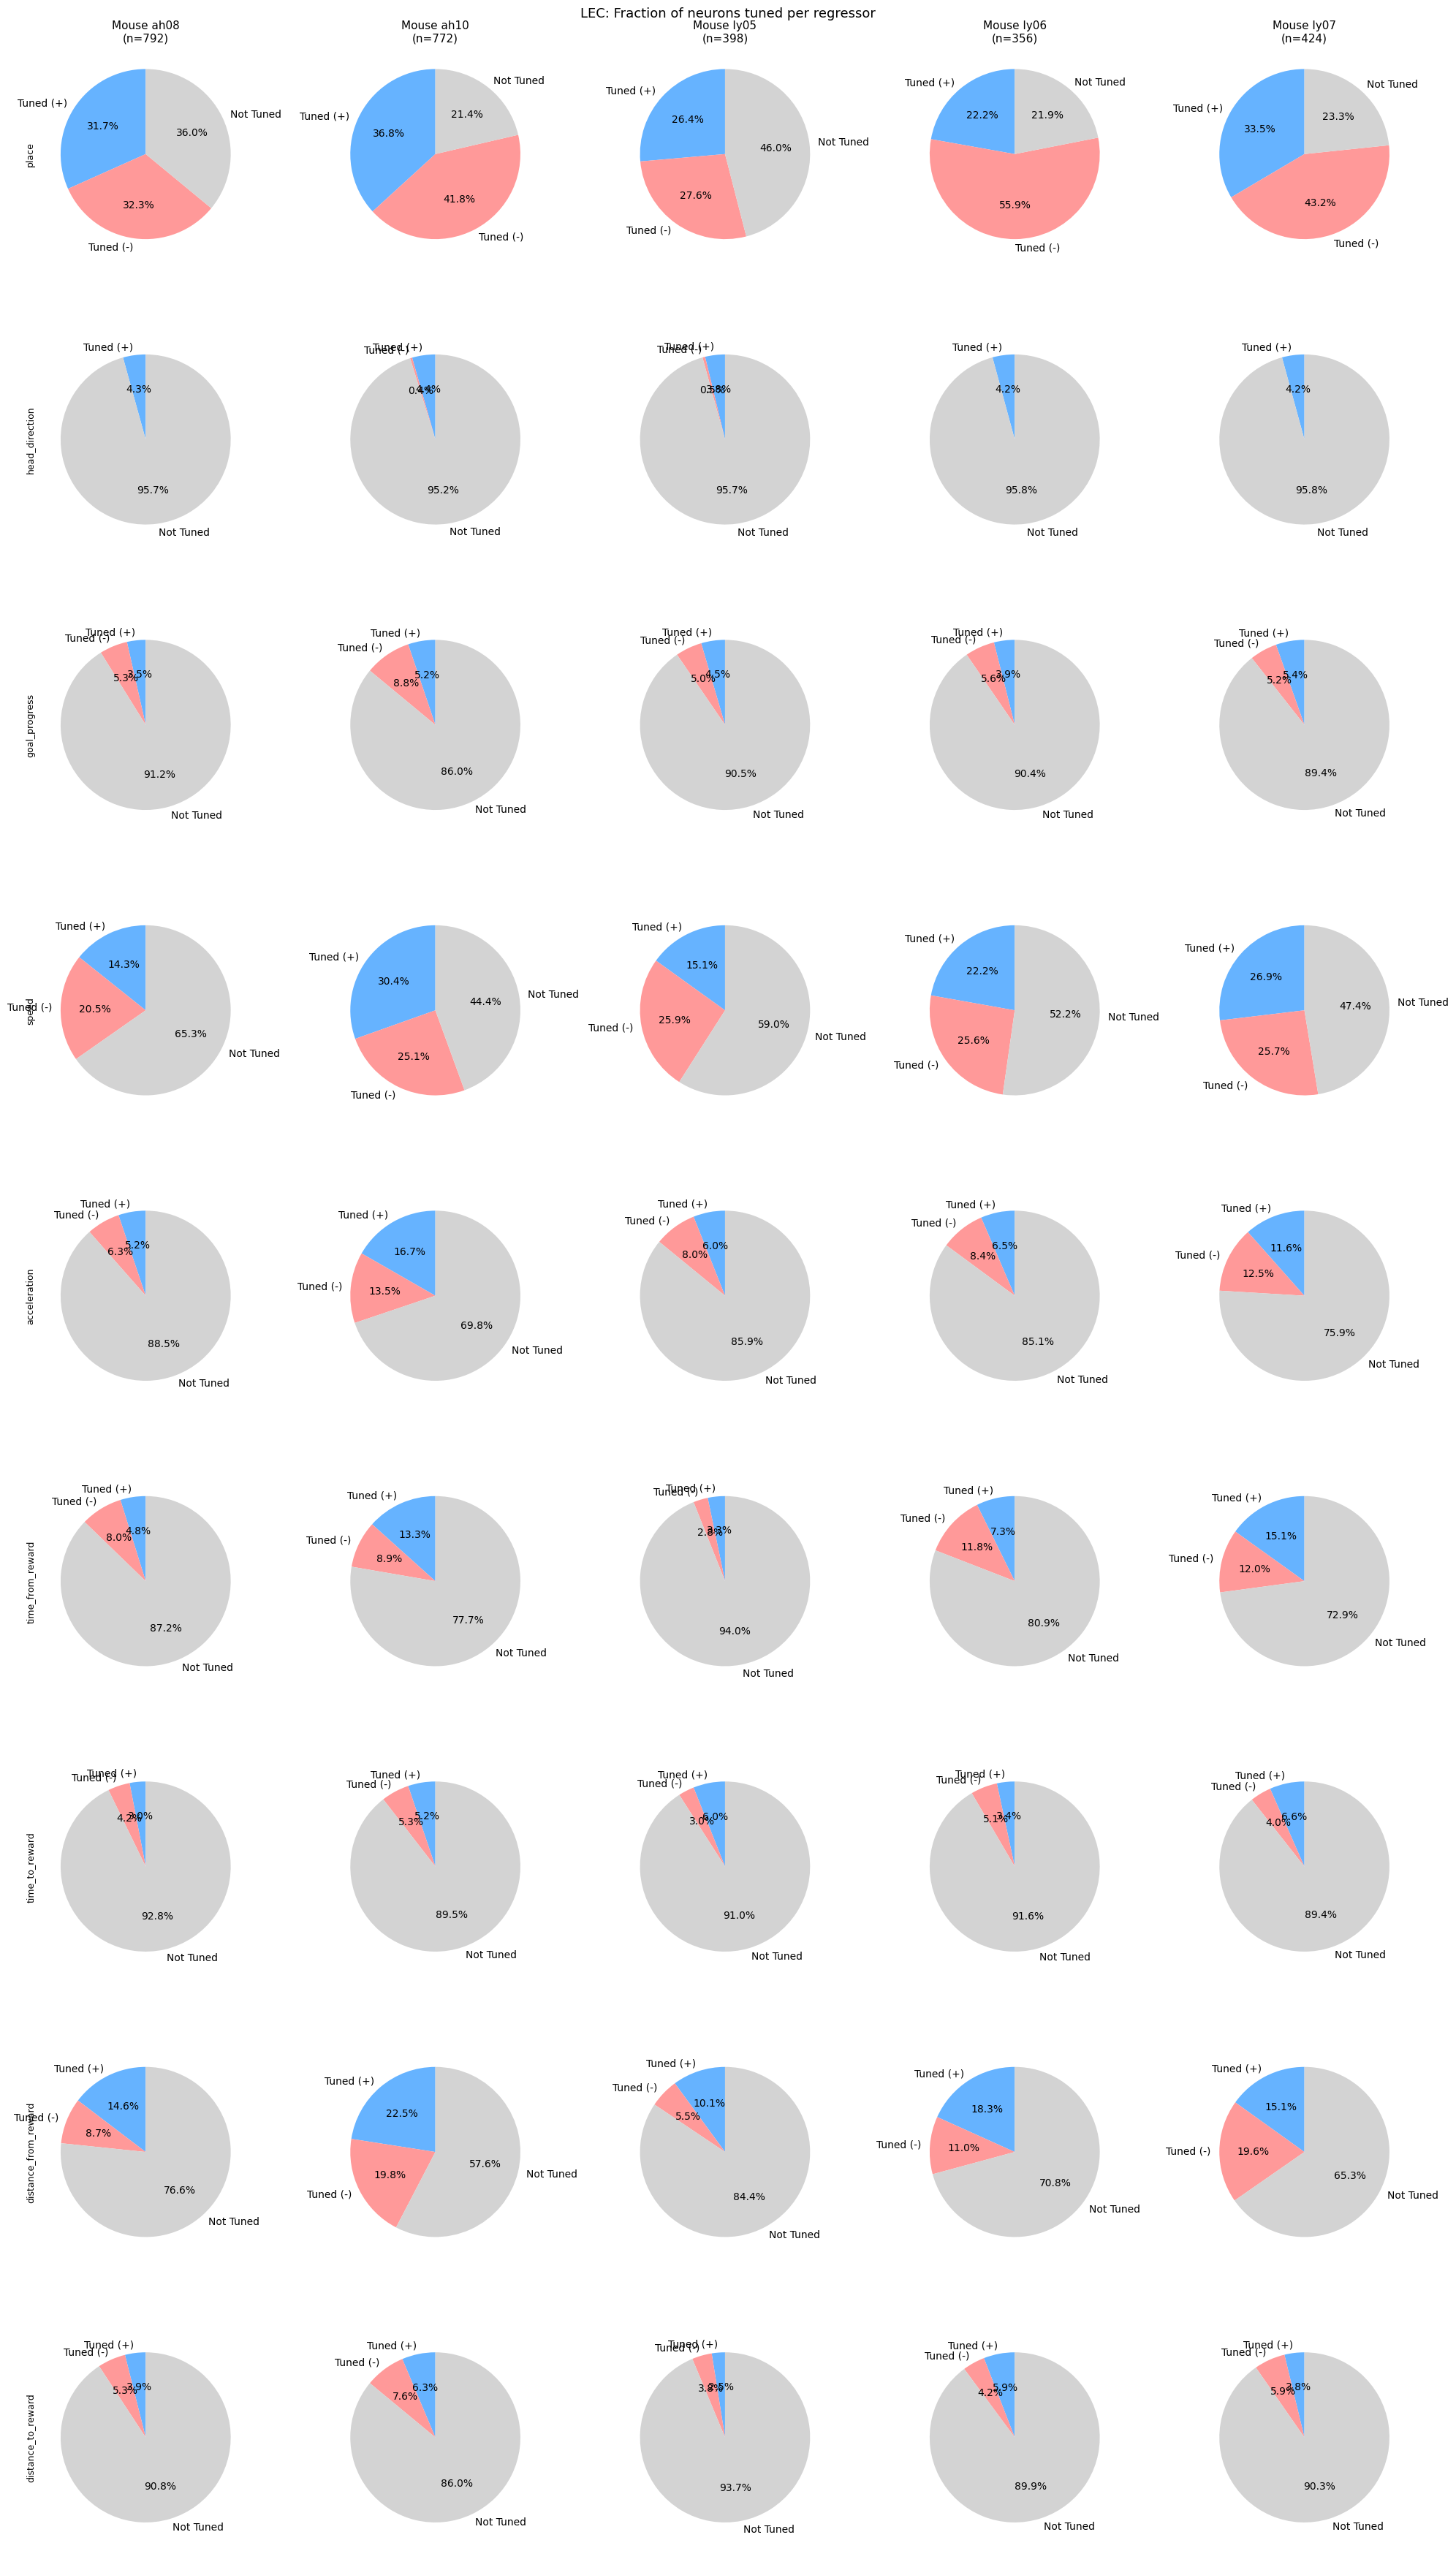

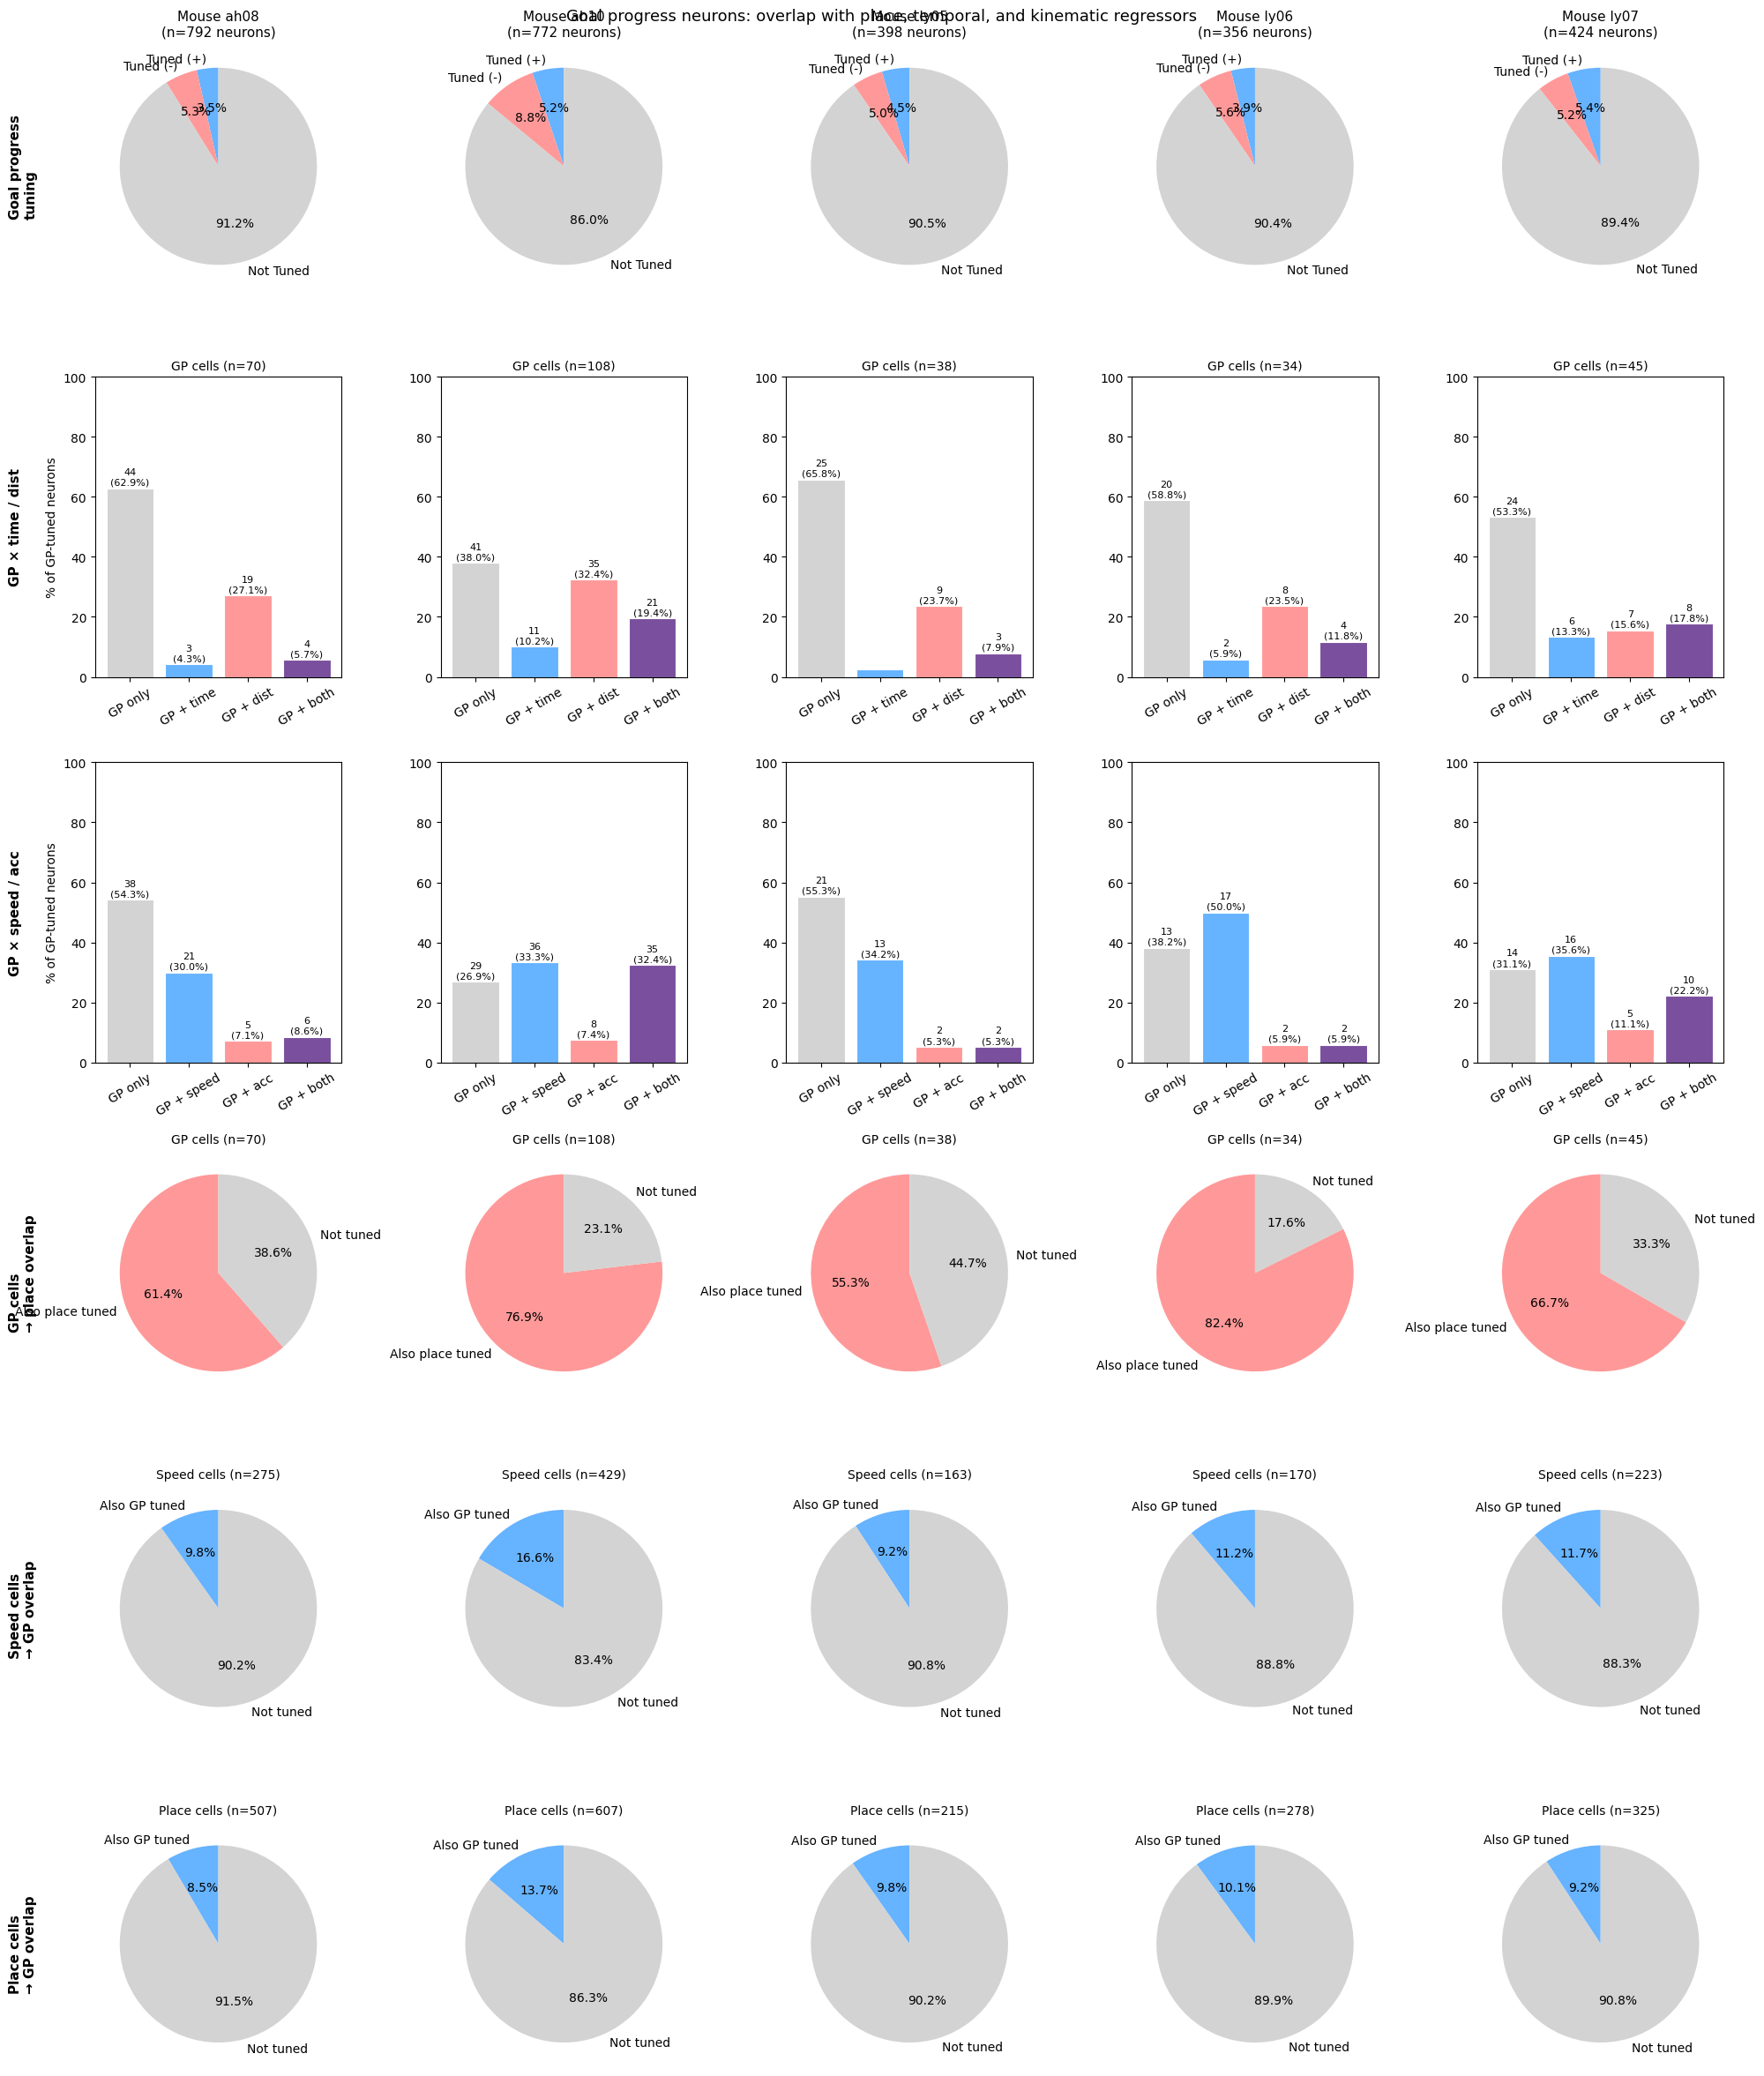


Tuning Summary:

Mouse ah08 (n=792):
  place: 507/792 (64.0%)  [251+ / 256-]
  head_direction: 34/792 (4.3%)  [34+ / 0-]
  goal_progress: 70/792 (8.8%)  [28+ / 42-]
  speed: 275/792 (34.7%)  [113+ / 162-]
  acceleration: 91/792 (11.5%)  [41+ / 50-]
  time_from_reward: 101/792 (12.8%)  [38+ / 63-]
  time_to_reward: 57/792 (7.2%)  [24+ / 33-]
  distance_from_reward: 185/792 (23.4%)  [116+ / 69-]
  distance_to_reward: 73/792 (9.2%)  [31+ / 42-]

Mouse ah10 (n=772):
  place: 607/772 (78.6%)  [284+ / 323-]
  head_direction: 37/772 (4.8%)  [34+ / 3-]
  goal_progress: 108/772 (14.0%)  [40+ / 68-]
  speed: 429/772 (55.6%)  [235+ / 194-]
  acceleration: 233/772 (30.2%)  [129+ / 104-]
  time_from_reward: 172/772 (22.3%)  [103+ / 69-]
  time_to_reward: 81/772 (10.5%)  [40+ / 41-]
  distance_from_reward: 327/772 (42.4%)  [174+ / 153-]
  distance_to_reward: 108/772 (14.0%)  [49+ / 59-]

Mouse ly05 (n=398):
  place: 215/398 (54.0%)  [105+ / 110-]
  head_direction: 17/398 (4.3%)  [15+ / 2-]
  goal_p

In [ ]:
from glm_analysis_v2 import (
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts,
    plot_gp_overlap,
    print_tuning_summary,
)

tuned_dict = compute_tuning_arrays(GLM_results, Permutation_results)
mouse_tuning_concat = group_tuning_by_mouse(tuned_dict)

plot_tuning_piecharts(mouse_tuning_concat)
plot_gp_overlap(mouse_tuning_concat)
print_tuning_summary(mouse_tuning_concat)

## Sanity check: decile distributions

Pools the same values that `run_glm_analysis` feeds to `compute_decile_edges`
(after the `Locs <= 21` filter, after downsampling), and overlays the chosen
decile boundaries plus the 1st/99th-percentile clip lines. Quick visual
confirmation that each variable's bins land where you'd expect — e.g. that
`time_from_reward` isn't so spiky at 0 that several deciles collapse.

In [ ]:
from glm_analysis_v2 import plot_decile_distributions
pooled = plot_decile_distributions(mouse_recdays, data_dic)

In [ ]:
example_neuron_tunings = tuned_dict['ly07_20250616_20250617'][20]
regressor_group_ids = ['place',
'head direction',
'goal progress',
'speed' ,
'acceleration',
'time-from-reward',
'time-to-reward',
'distance-from-reward',
'distance-to-reward']

for i, j in zip(regressor_group_ids, example_neuron_tunings):
    print(f"{i}: {j}")

place: 1
head direction: 0
goal progress: 0
speed: 0
acceleration: 0
time-from-reward: 1
time-to-reward: 0
distance-from-reward: -1
distance-to-reward: 0


## No-lookahead variant: GLM without `time_to_reward` and `distance_to_reward`

`time_to_reward` and `distance_to_reward` are **forward-looking** — they encode information about a reward that hasn't happened yet. That makes their relationship with `goal_progress` somewhat tautological: if the animal effectively "knows" how far the next reward is, that's almost by construction what goal-progress encodes.

Below we refit the GLM with these two regressors removed and re-run the same tuning analysis. If `goal_progress` tuning largely survives the removal, it suggests neurons encode progress from intrinsic cues (e.g., time/distance since *last* reward, place, head direction) rather than purely lookahead. If GP tuning collapses, much of the apparent signal was driven by the forward-looking variables.

In [ ]:
# Variant without forward-looking regressors (time_to_reward, distance_to_reward).
# Same pipeline; only the design-matrix subset changes.

reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis,
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts,
    plot_gp_overlap,
    print_tuning_summary,
)

included = [
    'place', 'head_direction', 'goal_progress',
    'speed', 'acceleration',
    'time_from_reward', 'distance_from_reward',
]

GLM_results_nl, Permutation_results_nl = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=included,
)

tuned_dict_nl = compute_tuning_arrays(
    GLM_results_nl, Permutation_results_nl,
    regressors_to_include=included,
)
mouse_tuning_concat_nl = group_tuning_by_mouse(tuned_dict_nl)

plot_tuning_piecharts(mouse_tuning_concat_nl, regressors_to_include=included)
plot_gp_overlap(mouse_tuning_concat_nl, regressors_to_include=included)
print_tuning_summary(mouse_tuning_concat_nl, regressors_to_include=included)

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 107 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'distance_from_reward'])


Processing recording days:   0%|          | 0/24 [00:25<?, ?it/s]


KeyboardInterrupt: 

**Interpretation**: compare the pie charts above (all 9 regressors) vs below (7 regressors). If `goal_progress` tuning fractions drop dramatically when the lookahead variables are removed, the original GP signal was substantially driven by them. If GP fractions are stable, neurons are tuned to progress independent of the lookahead variables.

## Extended analysis: full regressors, time vs goal-progress focus, CPD

Builds on the analyses above. **All existing cells preserved**; this section adds parallel outputs for the questions we actually care about going forward.

What's new vs the cells above:

1. **All 9 regressors back in** — `time_to_reward` and `distance_to_reward` are reintroduced (they were dropped in the no-lookahead cell).
2. **Renamed for clarity** — `time_from_reward` is now also accessible as `time_since_reward` (the old name still works; both map to the same internal variable). Plot labels show the clearer phrasing. Same for `distance_*`.
3. **Simplified pie charts** — 2-slice (Tuned vs Not Tuned) rather than 3-slice (+/-/not). We mostly care about *whether* a neuron is significantly tuned, not the sign.
4. **Joint "time" test** — a single F-test that drops both time-since and time-to-reward together, asking: "is *any* time information significant?" Stored as `time_any`.
5. **Coefficient of Partial Determination (CPD)** computed per neuron per regressor. CPD = (RSS_reduced − RSS_full) / RSS_reduced — the proportion of unexplained variance that drops when this variable is added. An *effect size* that complements the F-test's *significance*.

### A note on CPD

The F-test tells you **whether** a variable matters (significance, dependent on sample size). CPD tells you **how much** it matters (effect size, sample-size-independent). A neuron can be highly *significant* for two variables yet have very different CPDs — meaning one explains much more unique variance than the other.

Definition: $\text{CPD}_X = \dfrac{\text{RSS}_{\text{reduced (no X)}} - \text{RSS}_{\text{full}}}{\text{RSS}_{\text{reduced (no X)}}}$

Bounded in $[0, 1]$. Comparing $\text{CPD}_{\text{goal progress}}$ vs $\text{CPD}_{\text{time}}$ per neuron lets us ask whether progress carries more *unique* signal than time, or vice versa, or whether they're substitutable (high CPDs for both).

In [ ]:
# Re-fit GLM with all 9 regressors, CPD, and a joint 'time_any' test.
# Aliases (time_since_reward, distance_since_reward) work in the include list
# and in joint_drop_groups — internal names stay canonical.

reload(glm_analysis_v2)
from glm_analysis_v2 import run_glm_analysis

GLM_results_ext, Permutation_results_ext, CPD_results_ext = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=None,            # all 9 regressors
    compute_cpd=True,
    joint_drop_groups=[
        ('time_any', ['time_since_reward', 'time_to_reward']),
    ],
)
print('Done. CPD and joint time_any stored.')

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   4%|▍         | 1/24 [03:04<1:10:39, 184.33s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   8%|▊         | 2/24 [05:48<1:03:08, 172.21s/it]

...


ly07_20250620_20250623
  Design matrix: 15405 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:  96%|█████████▌| 23/24 [49:37<01:37, 97.88s/it]


ly07_20250624_20250625
  Design matrix: 13206 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days: 100%|██████████| 24/24 [51:04<00:00, 127.68s/it]

Done. CPD and joint time_any stored.


ah08_20250613_20250615: tuning array shape = (151, 9)
ah08_20250616_20250617: tuning array shape = (164, 9)
ah08_20250618_20250619: tuning array shape = (183, 9)
ah08_20250620_20250623: tuning array shape = (108, 9)
ah08_20250624_20250625: tuning array shape = (186, 9)
ah10_20250613_20250615: tuning array shape = (139, 9)
ah10_20250616_20250617: tuning array shape = (154, 9)
ah10_20250618_20250619: tuning array shape = (162, 9)
ah10_20250620_20250623: tuning array shape = (153, 9)
ah10_20250624_20250625: tuning array shape = (164, 9)
ly05_20250613_20250615: tuning array shape = (117, 9)
ly05_20250616_20250617: tuning array shape = (116, 9)
ly05_20250618_20250619: tuning array shape = (91, 9)
ly05_20250624_20250625: tuning array shape = (74, 9)
ly06_20250613_20250615: tuning array shape = (68, 9)
ly06_20250616_20250617: tuning array shape = (79, 9)
ly06_20250618_20250619: tuning array shape = (76, 9)
ly06_20250620_20250623: tuning array shape = (67, 9)
ly06_20250624_20250625: tuning arr

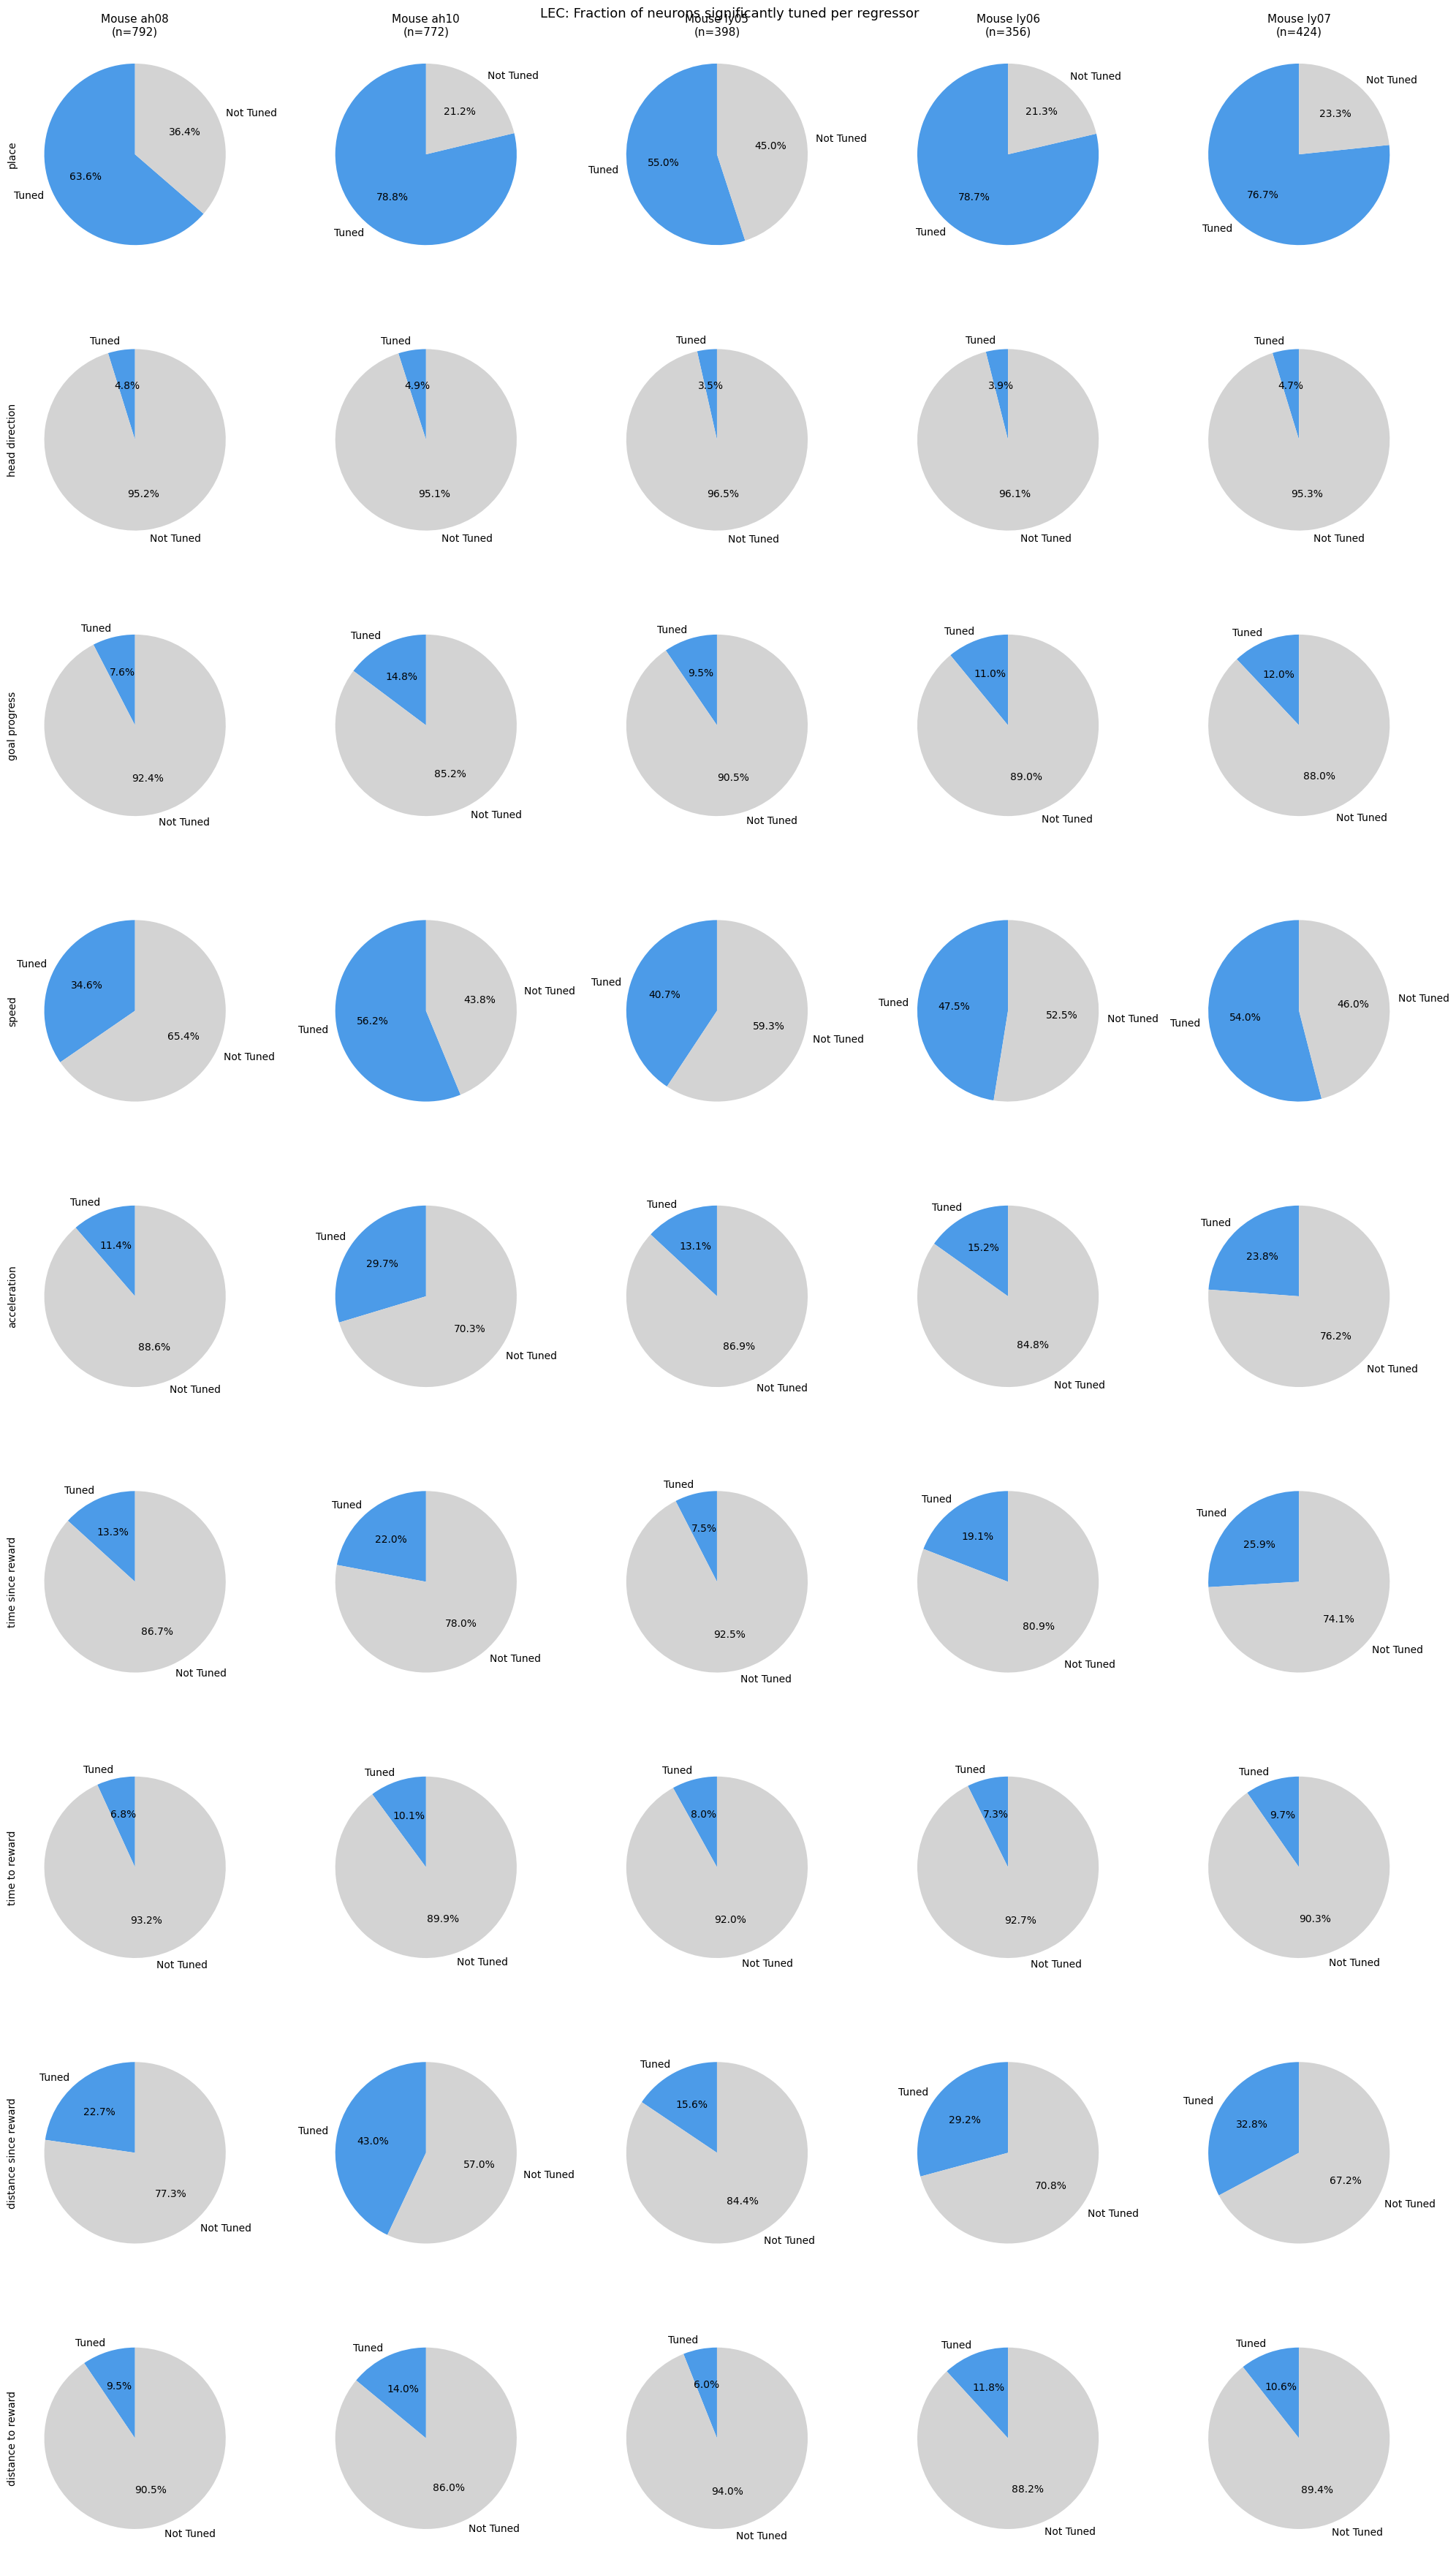

In [ ]:
# Compute tuning arrays and produce simplified (2-slice) pie charts.
# Note: tuned_dict uses the standard 9 regressors; the joint 'time_any'
# is in CPD_results but isn't tracked as a tuning class in tuned_dict.

from glm_analysis_v2 import (
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts_binary,
)

tuned_dict_ext = compute_tuning_arrays(GLM_results_ext, Permutation_results_ext)
mouse_tuning_concat_ext = group_tuning_by_mouse(tuned_dict_ext)

plot_tuning_piecharts_binary(mouse_tuning_concat_ext)

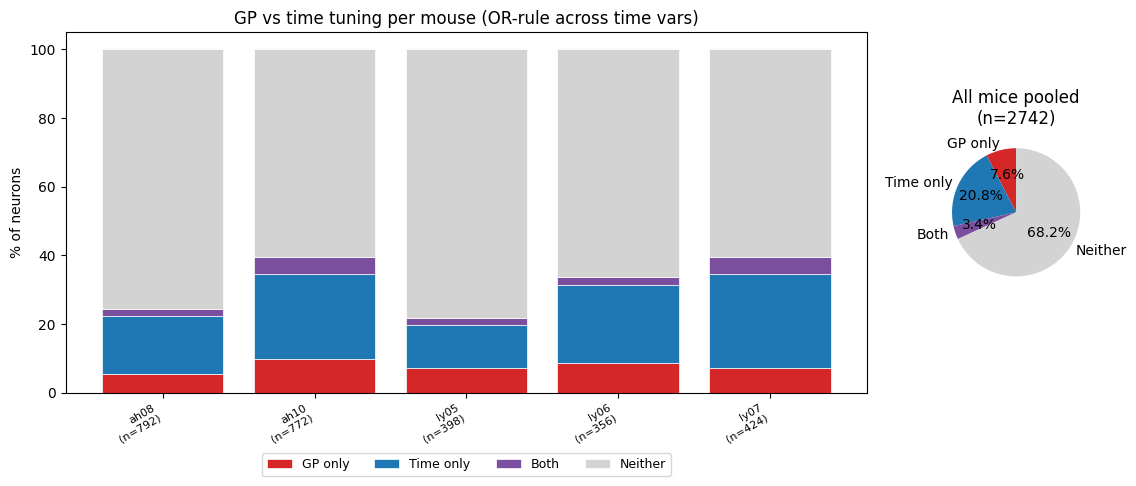

In [ ]:
# Time vs goal-progress overlap.
# OR-rule: a neuron is 'time-tuned' if it passes F-test for time_from OR time_to.
# Compares each neuron's GP-tuning to its time-tuning, four-way categorisation.

from glm_analysis_v2 import plot_time_vs_progress_overlap

plot_time_vs_progress_overlap(mouse_tuning_concat_ext, use_joint_time=False)

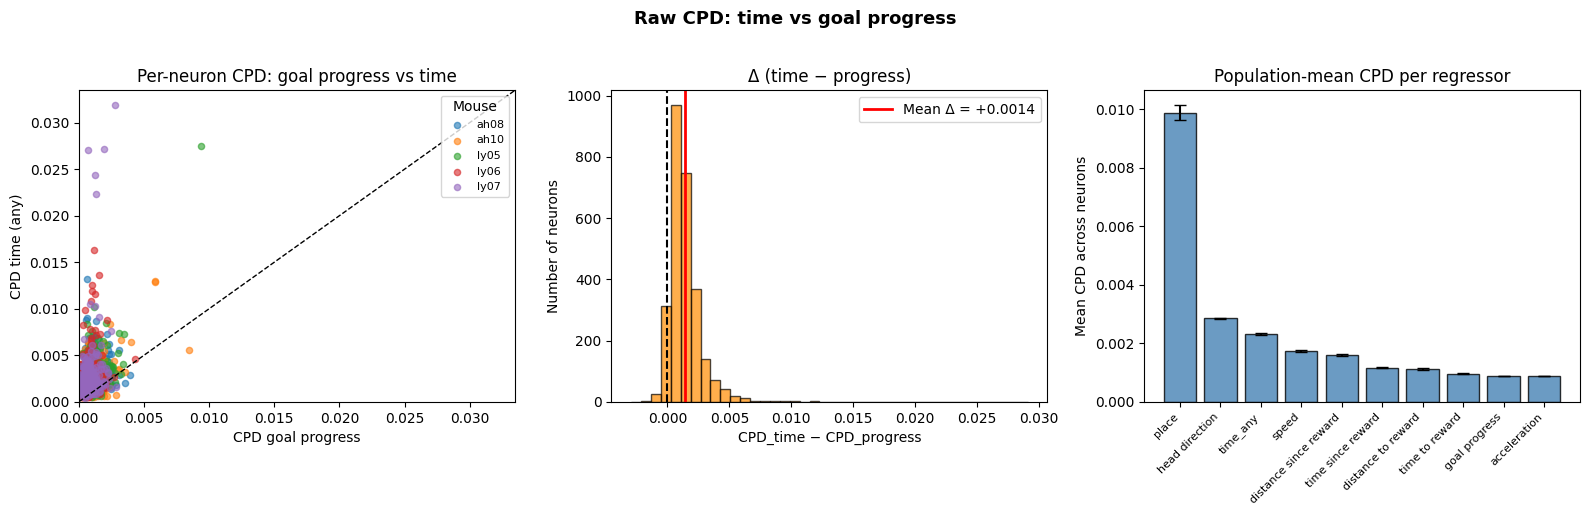

Per-mouse mean Δ (CPD_time − CPD_progress):
  ah08: μ=+0.00148  n=792
  ah10: μ=+0.00111  n=772
  ly05: μ=+0.00150  n=398
  ly06: μ=+0.00163  n=356
  ly07: μ=+0.00171  n=424


In [ ]:
# CPD comparison: per-neuron unique variance explained by goal progress vs time.
# Time CPD uses the joint 'time_any' group (single test) when available;
# falls back to max(CPD_time_from, CPD_time_to) otherwise.

from glm_analysis_v2 import plot_cpd_time_vs_progress

cpd_gp, cpd_time = plot_cpd_time_vs_progress(CPD_results_ext, group_by_mouse=True)

# Per-mouse-level paired test on CPD difference
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_any', np.nan)
        if not (np.isnan(g) or np.isnan(t)):
            by_mouse_diff[mouse].append(t - g)

print('Per-mouse mean Δ (CPD_time − CPD_progress):')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

### Reading these figures

- **2-slice pie charts**: each panel shows the fraction of neurons in one mouse that pass the F-test for that variable. Direct readout of "how prevalent is X-tuning?".
- **Time-vs-progress overlap**: tells you whether GP-tuned and time-tuned neurons are the *same population* (mostly "Both" + small "only" slices) or *distinct populations* (mostly "GP only" and "Time only"). Important for whether goal progress is a separable code or a re-description of time.
- **CPD scatter**: each dot is a neuron. Points above the diagonal → time explains more unique variance for that neuron; below → progress does. A cloud near zero on both axes is also informative ("these neurons are tuned to something, but neither time nor progress uniquely").
- **CPD Δ histogram**: if centred at 0, time and progress carry similar unique variance on average. Shifted left (negative) → progress dominates; shifted right → time dominates.

## Firming up: model fit quality, normalized CPD, column-matched comparison

The raw CPD values are tiny (~0.001–0.01). That's expected — single-neuron firing is mostly irreducible noise, and CPD measures *unique* partial variance after all other (correlated) regressors. These cells contextualise the magnitudes:

1. **Full-model R²** — how much variance the GLM explains at all. Anchors the CPD scale ("time uniquely explains 0.2% of residual, out of a model that explains ~8% total").
2. **Normalized CPD** = ΔR² / R²_full — the fraction of the model's *explainable* variance uniquely attributable to each regressor. Reads more naturally than raw CPD.
3. **Column-matched time vs progress** — compares `goal_progress` (10 cols) to `time_since_reward` *alone* (10 cols), instead of the joint 20-col `time_any`, so the headline comparison isn't confounded by column count.

Re-run the extended-fit cell above first (it now stores `__r2_full__` and `__delta_r2__` in `CPD_results_ext` automatically).

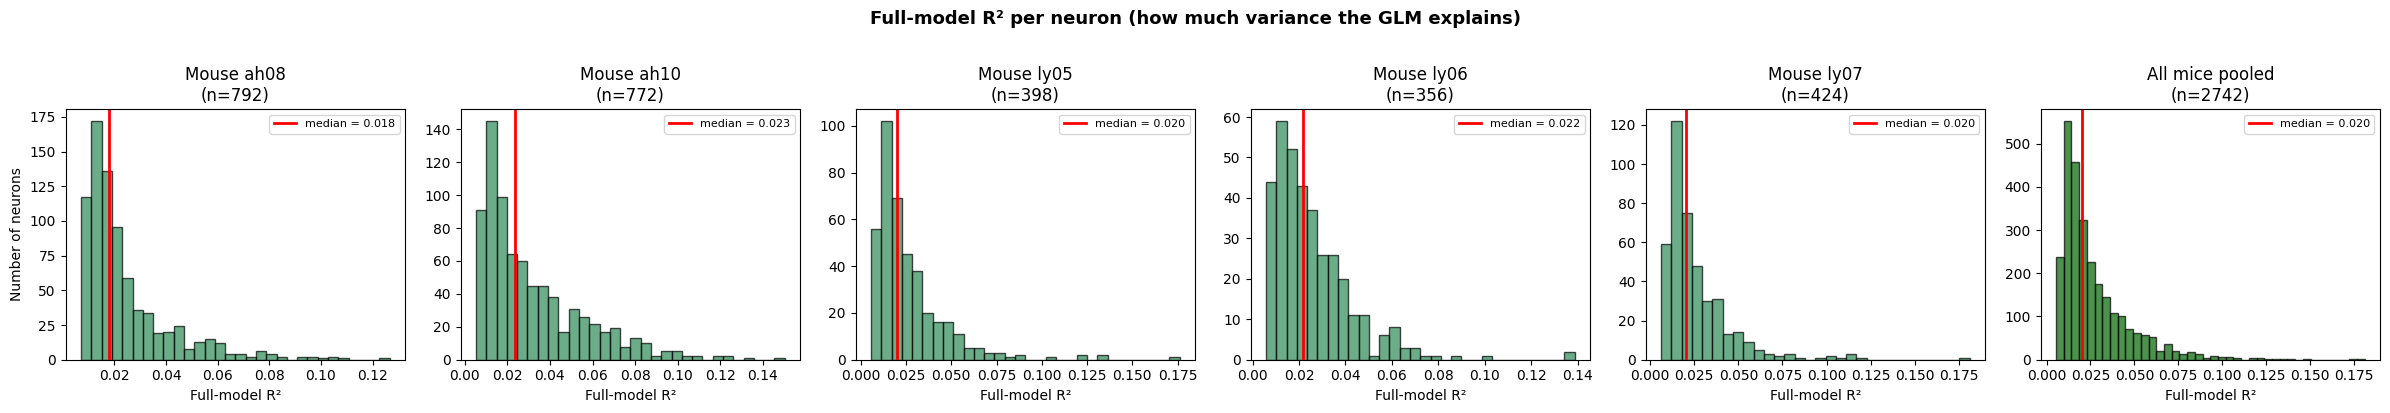

Pooled full-model R²: median=0.0201, mean=0.0271, 90th pct=0.0544


In [ ]:
# Full-model R² per neuron — how much variance the GLM explains at all.
reload(glm_analysis_v2)
from glm_analysis_v2 import plot_full_model_r2

r2_by_mouse = plot_full_model_r2(CPD_results_ext)
import numpy as np
pooled_r2 = np.concatenate(list(r2_by_mouse.values()))
print(f'Pooled full-model R²: median={np.median(pooled_r2):.4f}, '
      f'mean={np.mean(pooled_r2):.4f}, 90th pct={np.percentile(pooled_r2, 90):.4f}')

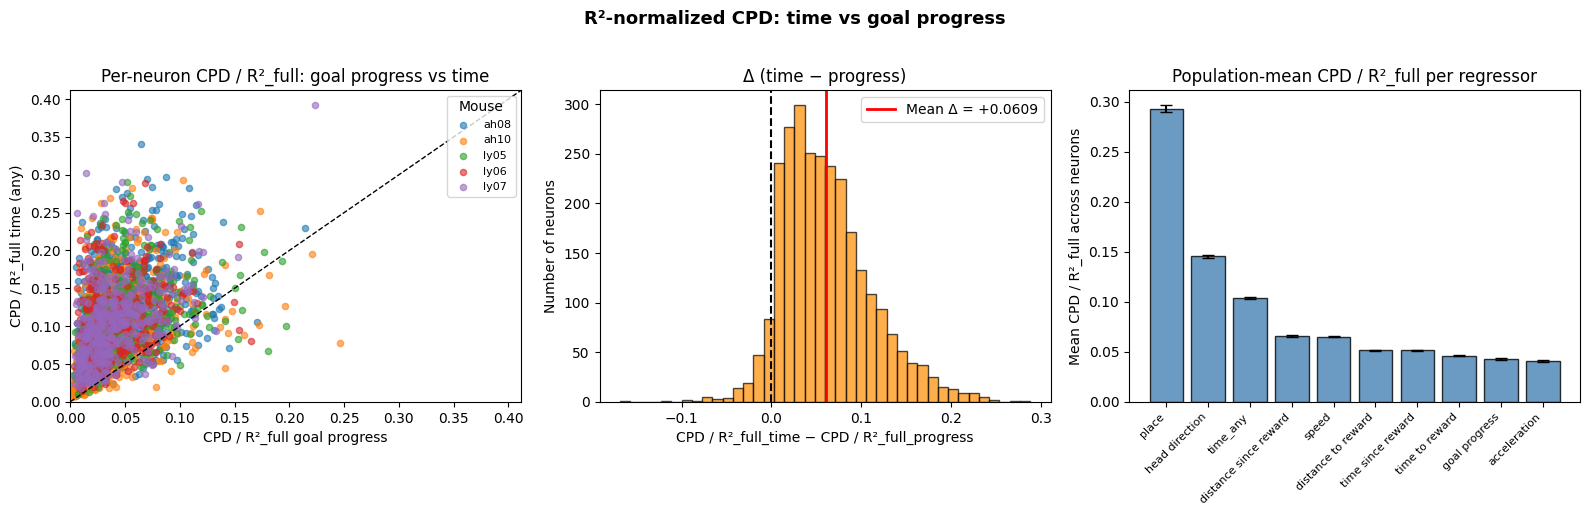

(array([0.09365515, 0.03955018, 0.04568938, ..., 0.00902194, 0.03868477,
        0.01637261]),
 array([0.21124354, 0.07186066, 0.18368051, ..., 0.03138969, 0.13104865,
        0.02936778]))

In [ ]:
# Normalized CPD: fraction of the model's explainable variance uniquely
# attributable to time vs goal progress (ΔR² / R²_full).
from glm_analysis_v2 import plot_cpd_time_vs_progress

plot_cpd_time_vs_progress(CPD_results_ext, group_by_mouse=True, normalize='r2_full')

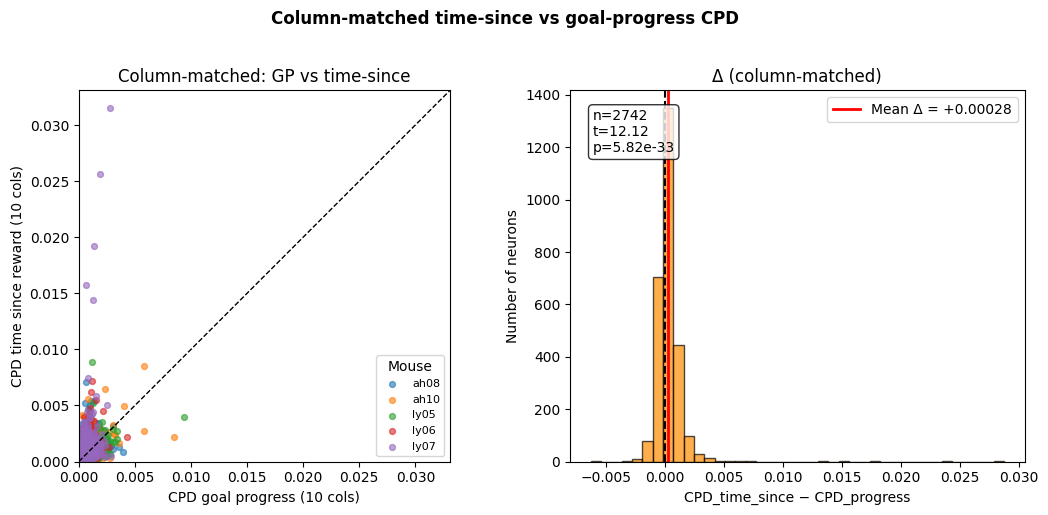

In [ ]:
# Column-matched comparison: goal_progress (10 cols) vs time_since_reward (10 cols),
# NOT the joint 20-col time_any. Removes the column-count advantage from the
# headline time-vs-progress claim.

gp_cpd, ts_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_from_reward', np.nan)  # time_since_reward (10 cols)
        if np.isfinite(g) and np.isfinite(t):
            gp_cpd.append(g); ts_cpd.append(t); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); ts_cpd = np.array(ts_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], ts_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), ts_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (10 cols)')
ax.set_ylabel('CPD time since reward (10 cols)')
ax.set_title('Column-matched: GP vs time-since')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = ts_cpd - gp_cpd
ax.hist(d, bins=40, color='darkorange', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean Δ = {d.mean():+.5f}')
from scipy import stats as _st
tval, pval = _st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_time_since − CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Δ (column-matched)')
ax.legend()
plt.suptitle('Column-matched time-since vs goal-progress CPD', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Raised-cosine basis variant (robustness check)

Re-fits the GLM with the continuous regressors encoded as **smooth raised-cosine bumps** instead of hard decile bins. Design choices:

- **Log-stretched spacing** for the reward-relative variables (time/distance since/to reward) — concentrates resolution near the reward event. **Linear** for speed, acceleration, and goal progress.
- **10 basis functions** per variable (matches the decile column count) → the design matrix is the same 127 columns, so the F-test, CPD, and overlap analyses are directly comparable to the one-hot version above.
- **Place and head direction stay one-hot** (place is a discrete graph; HD is circular and needs a periodic basis, out of scope here).
- Goal progress is converted too, so the time-vs-progress comparison is representation-matched.

This tests whether time > progress is robust to the *representation*, not just the content. Hard-vs-smooth binning rarely flips a population effect, so this is a confirm-it-doesn't-change pass rather than the decisive test (the column-matched comparison above is the decisive one).

In [ ]:
# Re-fit with raised-cosine basis for the continuous variables.
reload(glm_analysis_v2)
from glm_analysis_v2 import run_glm_analysis

GLM_results_rc, Permutation_results_rc, CPD_results_rc = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=None,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    continuous_basis='raised_cosine',
)
print('Raised-cosine fit done.')

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   4%|▍         | 1/24 [03:09<1:12:46, 189.84s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   8%|▊         | 2/24 [05:54<1:04:06, 174.83s/it]

...


ly07_20250620_20250623
  Design matrix: 15405 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:  96%|█████████▌| 23/24 [49:59<01:38, 98.83s/it]


ly07_20250624_20250625
  Design matrix: 13206 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days: 100%|██████████| 24/24 [51:28<00:00, 128.70s/it]

Raised-cosine fit done.


ah08_20250613_20250615: tuning array shape = (151, 9)
ah08_20250616_20250617: tuning array shape = (164, 9)
ah08_20250618_20250619: tuning array shape = (183, 9)
ah08_20250620_20250623: tuning array shape = (108, 9)
ah08_20250624_20250625: tuning array shape = (186, 9)
ah10_20250613_20250615: tuning array shape = (139, 9)
ah10_20250616_20250617: tuning array shape = (154, 9)
ah10_20250618_20250619: tuning array shape = (162, 9)
ah10_20250620_20250623: tuning array shape = (153, 9)
ah10_20250624_20250625: tuning array shape = (164, 9)
ly05_20250613_20250615: tuning array shape = (117, 9)
ly05_20250616_20250617: tuning array shape = (116, 9)
ly05_20250618_20250619: tuning array shape = (91, 9)
ly05_20250624_20250625: tuning array shape = (74, 9)
ly06_20250613_20250615: tuning array shape = (68, 9)
ly06_20250616_20250617: tuning array shape = (79, 9)
ly06_20250618_20250619: tuning array shape = (76, 9)
ly06_20250620_20250623: tuning array shape = (67, 9)
ly06_20250624_20250625: tuning arr

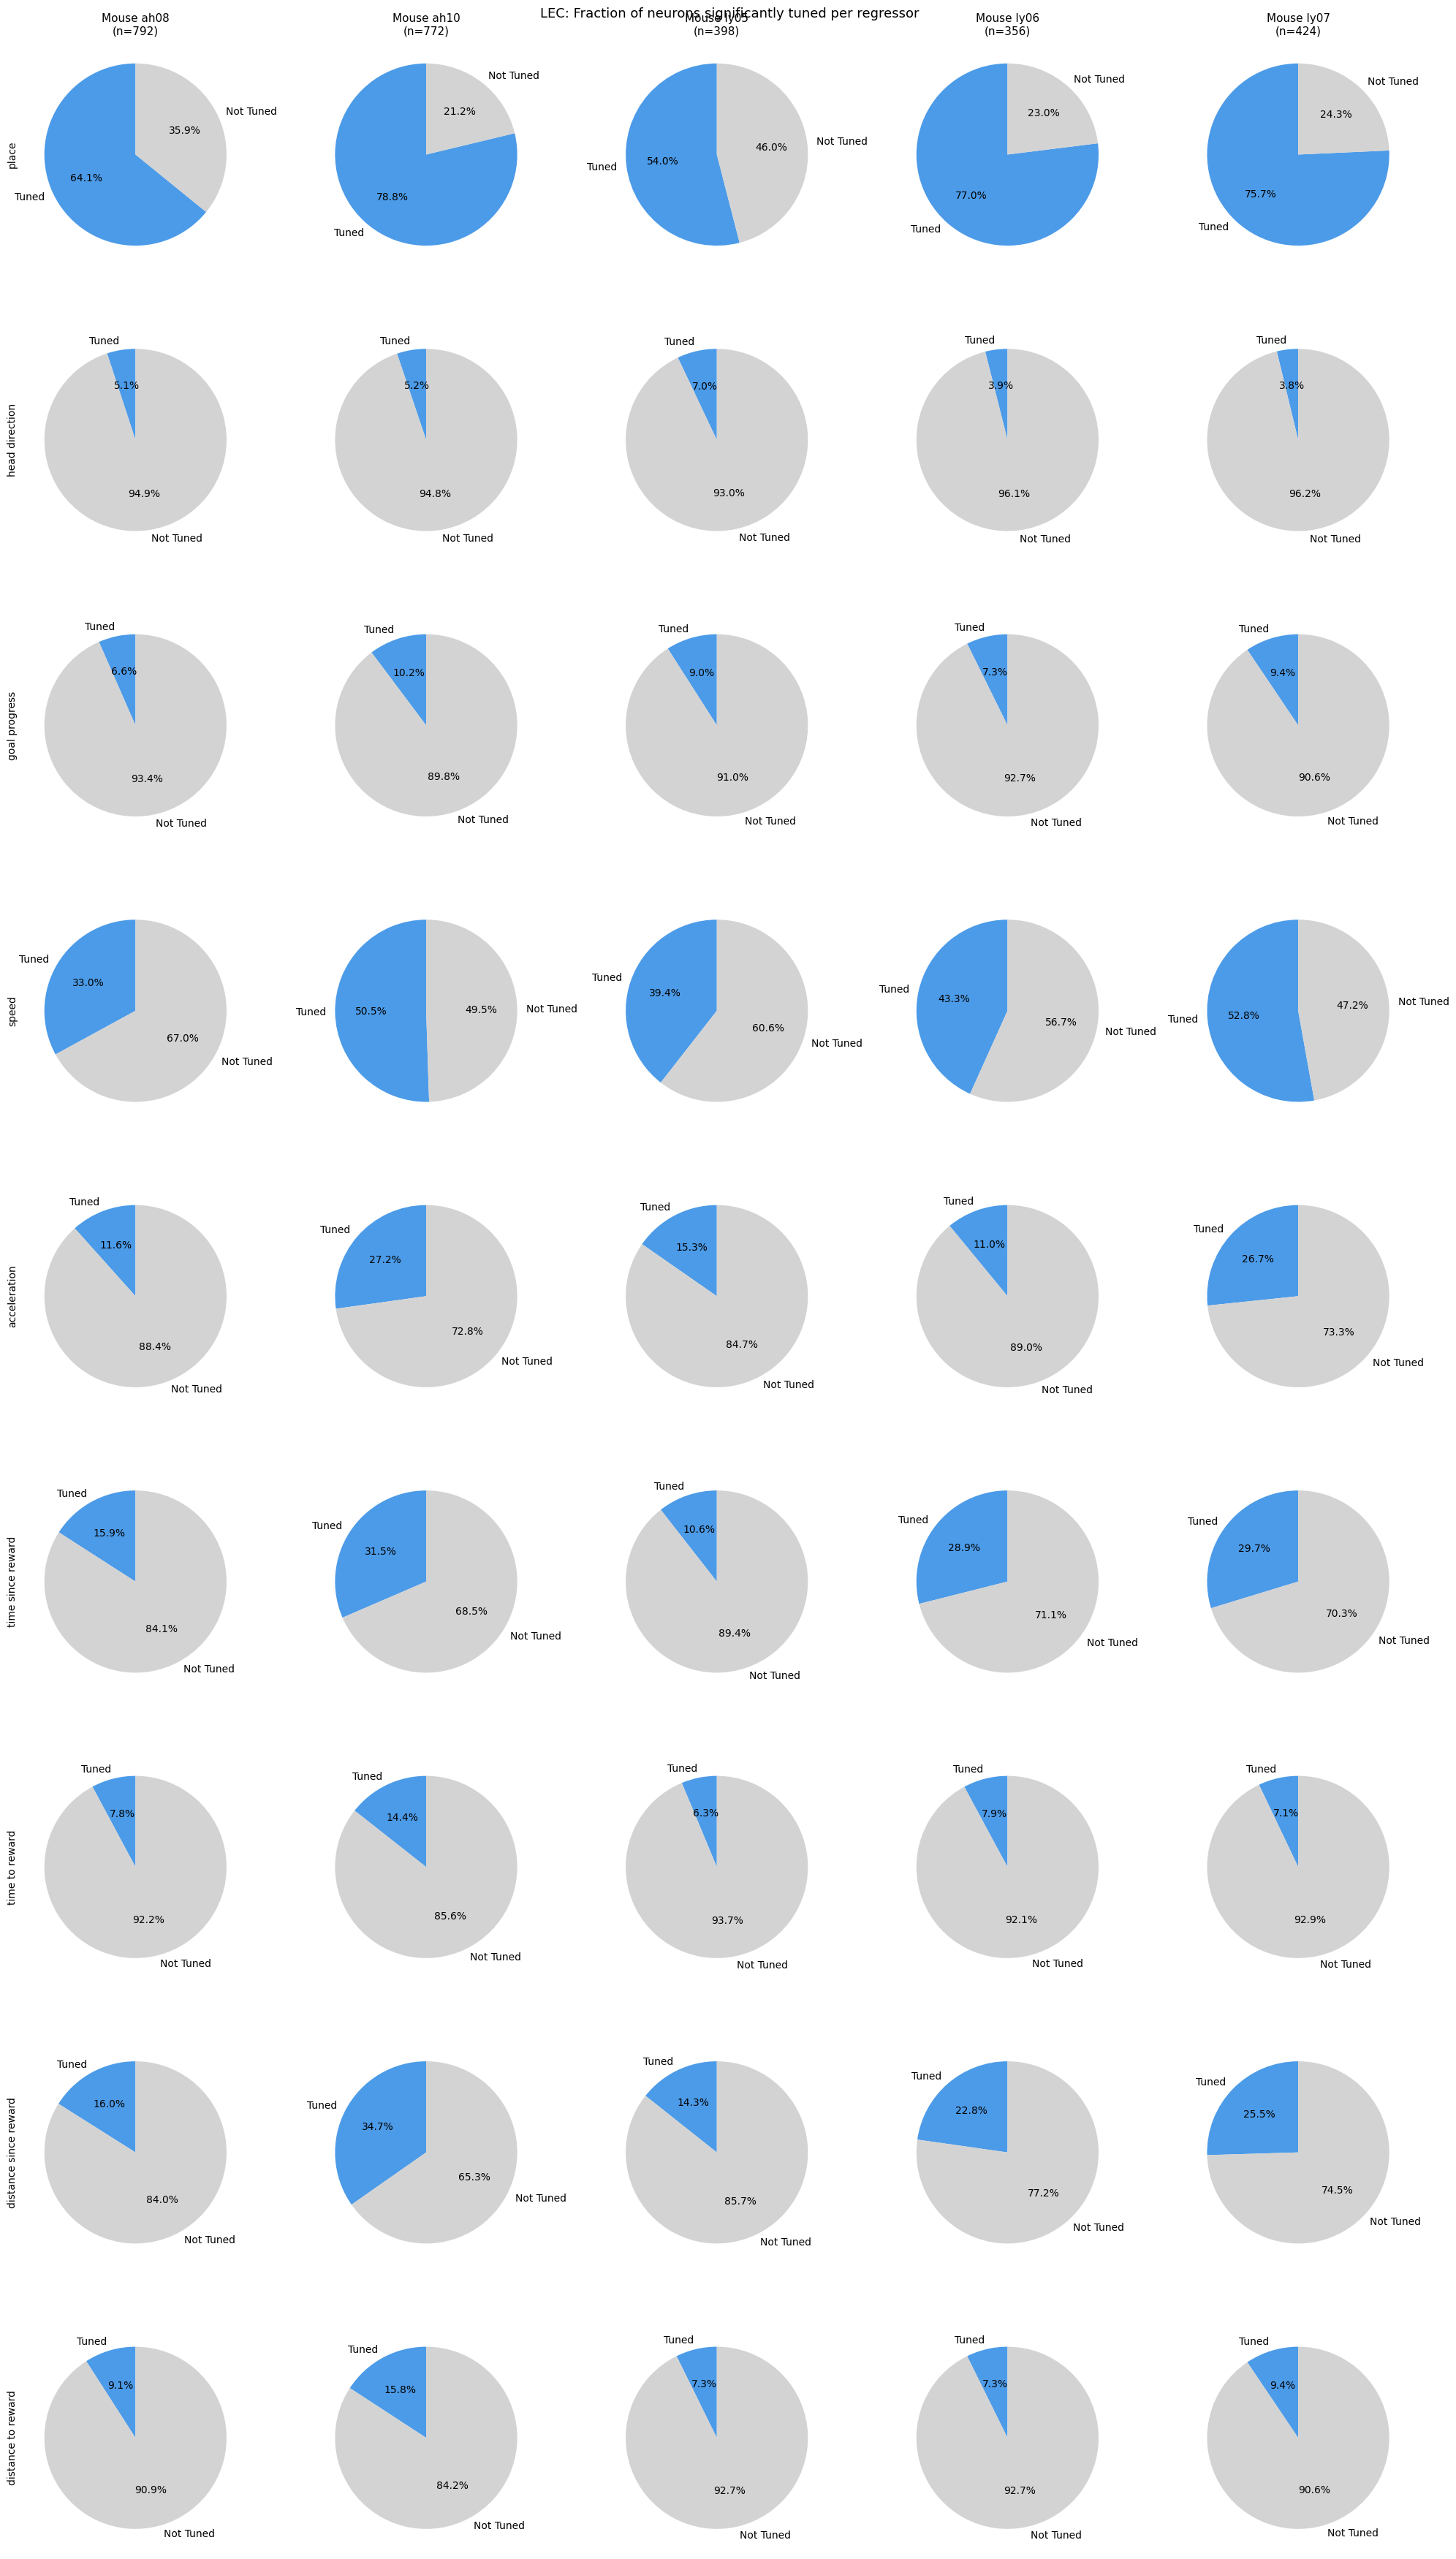

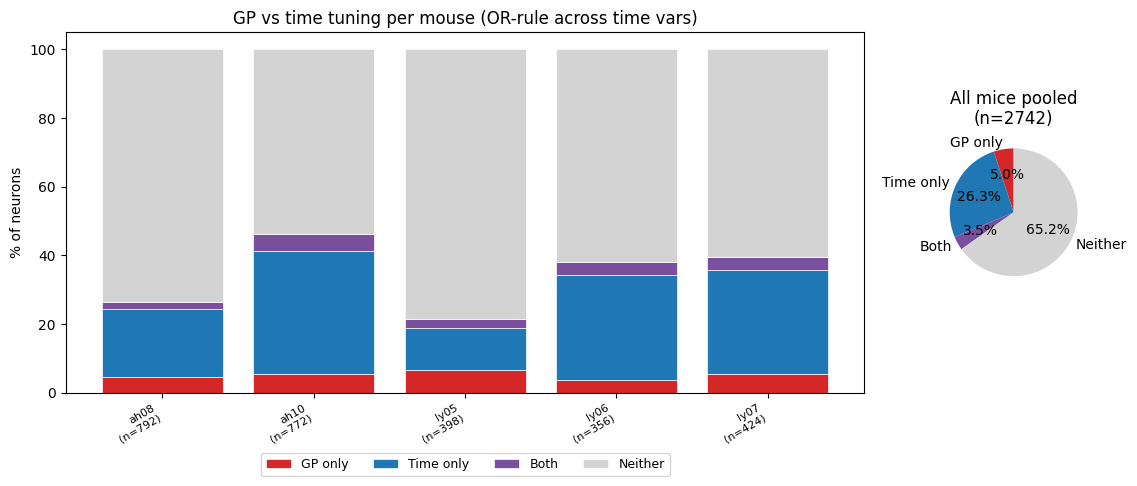

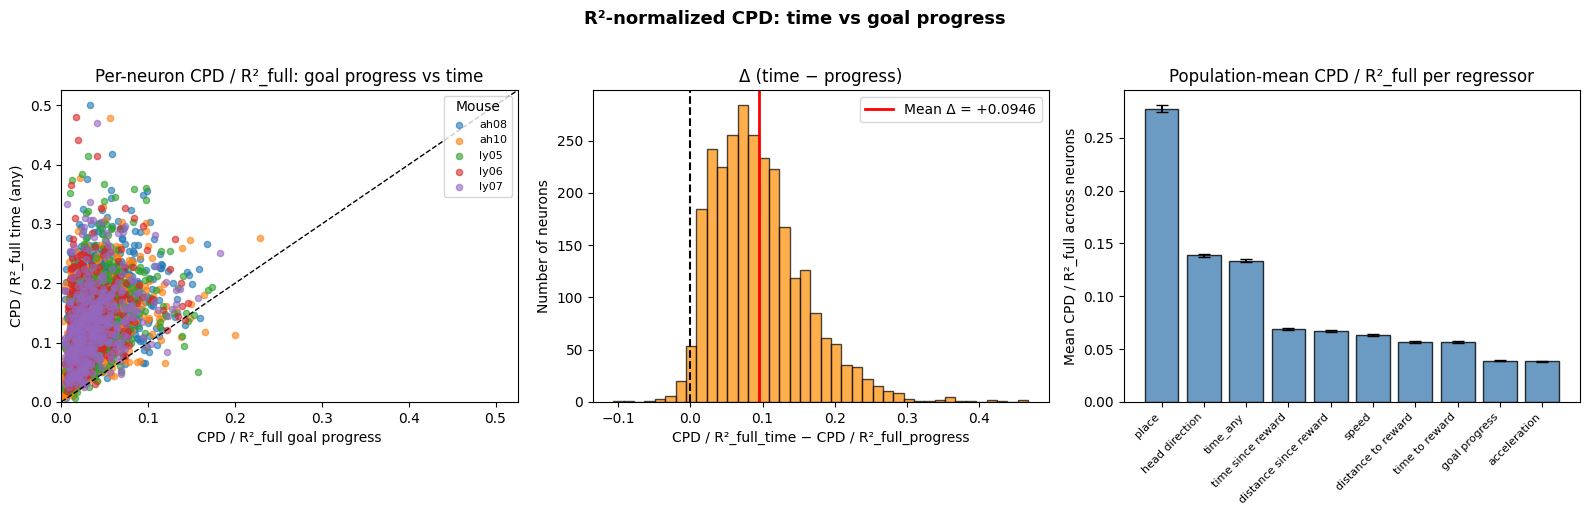

(array([0.11436033, 0.03679221, 0.04808196, ..., 0.00850023, 0.02625374,
        0.01679108]),
 array([0.23282835, 0.10281078, 0.30311362, ..., 0.11556893, 0.18468278,
        0.05245359]))

In [ ]:
# Raised-cosine results: pies, time-vs-progress overlap, CPD comparison.
from glm_analysis_v2 import (
    compute_tuning_arrays, group_tuning_by_mouse,
    plot_tuning_piecharts_binary, plot_time_vs_progress_overlap,
    plot_cpd_time_vs_progress,
)

tuned_dict_rc = compute_tuning_arrays(GLM_results_rc, Permutation_results_rc)
mouse_tuning_concat_rc = group_tuning_by_mouse(tuned_dict_rc)

plot_tuning_piecharts_binary(mouse_tuning_concat_rc)
plot_time_vs_progress_overlap(mouse_tuning_concat_rc, use_joint_time=False)
plot_cpd_time_vs_progress(CPD_results_rc, group_by_mouse=True, normalize='r2_full')

### One-hot vs raised-cosine: what to compare

Put the raised-cosine pies/overlap/CPD next to the one-hot versions above. If **time still exceeds progress** under the smooth basis (similar overlap fractions, CPD scatter still off-diagonal toward time), the result is not an artefact of hard decile binning. If it *weakens* substantially, time tuning may have been punctate/non-monotonic structure that the 10 smooth bumps can't represent as sharply — worth investigating with more basis functions. Either way, the column-matched single-variable comparison remains your primary fairness control.

## 20-bin goal-progress variant (column-matched to joint time / distance)

The headline time-vs-progress comparison above fits `goal_progress` with **10**
one-hot columns, but tests "time" via the joint `time_any` group
(`time_since_reward` + `time_to_reward` = **20** columns). More columns means more
flexibility, which gives a regressor a structural advantage in captured variance
(and therefore CPD). So `goal_progress` (10) vs `time_any` (20) is
**column-mismatched**.

Here we re-run the one-hot analysis with `gp_n_bins=20`, so `goal_progress` has
20 columns — matching both the 20-col `time_any` and the 20-col `distance_any`
groups. The design matrix grows from 127 to 137 columns. Everything else
(F-test, CPD, plots) is unchanged. This section is purely additive; the 10-bin
cells above are untouched.

In [ ]:
# 20-bin goal-progress fit, with joint time and distance groups (each 20 cols).
# gp_n_bins=20 column-matches goal_progress to time_any / distance_any.

reload(glm_analysis_v2)
from glm_analysis_v2 import run_glm_analysis

GLM_results_gp20, Permutation_results_gp20, CPD_results_gp20 = run_glm_analysis(
    mouse_recdays, data_dic,
    gp_n_bins=20,                          # goal progress -> 20 one-hot cols
    compute_cpd=True,
    joint_drop_groups=[
        ('time_any',     ['time_since_reward', 'time_to_reward']),
        ('distance_any', ['distance_since_reward', 'distance_to_reward']),
    ],
)
print('Done. Design matrix is 137 cols (GP=20); time_any / distance_any = 20 cols each.')

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 137 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   4%|▍         | 1/24 [03:39<1:24:04, 219.30s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 137 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:   8%|▊         | 2/24 [06:55<1:15:29, 205.90s/it]

...


ah10_20250616_20250617
  Design matrix: 16173 rows × 137 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:  29%|██▉       | 7/24 [23:45<57:38, 203.42s/it]


ah10_20250618_20250619
  Design matrix: 13335 rows × 137 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


Processing recording days:  33%|███▎      | 8/24 [27:07<54:08, 203.06s/it]


ah10_20250620_20250623
  Design matrix: 16636 rows × 137 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])


In [ ]:
# Tuning arrays + simplified (2-slice) pie charts for the 20-bin GP fit.
# Pass gp_n_bins=20 so _beta_direction indexes the 20 goal_progress betas correctly.

from glm_analysis_v2 import (
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts_binary,
)

tuned_dict_gp20 = compute_tuning_arrays(
    GLM_results_gp20, Permutation_results_gp20, gp_n_bins=20
)
mouse_tuning_concat_gp20 = group_tuning_by_mouse(tuned_dict_gp20)

plot_tuning_piecharts_binary(mouse_tuning_concat_gp20)

In [ ]:
# Time vs goal-progress overlap (20-bin GP). Overlap is computed at the
# regressor-name level (one column per regressor in the tuning array), so the
# bin count is irrelevant here -- mirrors the 10-bin overlap figure above.

from glm_analysis_v2 import plot_time_vs_progress_overlap

plot_time_vs_progress_overlap(mouse_tuning_concat_gp20, use_joint_time=False)

In [ ]:
# Column-matched headline CPD: GP(20 cols) vs time_any(20 cols).
# Removes the column-count advantage that time_any had over the 10-bin GP in
# the extended-analysis section above.

from glm_analysis_v2 import plot_cpd_time_vs_progress

cpd_gp20, cpd_time20 = plot_cpd_time_vs_progress(CPD_results_gp20, group_by_mouse=True)

# Per-mouse paired test on the CPD difference (time_any - goal_progress)
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_gp20.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_any', np.nan)
        if not (np.isnan(g) or np.isnan(t)):
            by_mouse_diff[mouse].append(t - g)

print('Per-mouse mean delta (CPD_time_any - CPD_progress), column-matched 20 vs 20:')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: mu={diffs.mean():+.5f}  n={len(diffs)}')

In [ ]:
# Column-matched distance comparison: GP(20 cols) vs distance_any(20 cols).
# Mirrors the time comparison above, for the (and distance) part of the request.

gp_cpd, da_cpd, mouse_tag = [], [], []
for mr, neuron_dict in CPD_results_gp20.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        d = cpd.get('distance_any', np.nan)
        if np.isfinite(g) and np.isfinite(d):
            gp_cpd.append(g); da_cpd.append(d); mouse_tag.append(mouse)
gp_cpd = np.array(gp_cpd); da_cpd = np.array(da_cpd); mouse_tag = np.array(mouse_tag)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]
for i, mouse in enumerate(sorted(np.unique(mouse_tag))):
    msk = mouse_tag == mouse
    ax.scatter(gp_cpd[msk], da_cpd[msk], alpha=0.6, s=18,
               color=plt.get_cmap('tab10')(i % 10), label=mouse)
lim = max(0.001, max(gp_cpd.max(), da_cpd.max()) * 1.05)
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
ax.set_xlabel('CPD goal progress (20 cols)')
ax.set_ylabel('CPD distance (any) (20 cols)')
ax.set_title('Column-matched: GP vs distance')
ax.legend(fontsize=8, title='Mouse')

ax = axes[1]
d = da_cpd - gp_cpd
ax.hist(d, bins=40, color='seagreen', alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(d.mean(), color='red', lw=2, label=f'Mean delta = {d.mean():+.5f}')
from scipy import stats as _st
tval, pval = _st.ttest_1samp(d, 0)
ax.text(0.05, 0.95, f'n={len(d)}\nt={tval:.2f}\np={pval:.2e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('CPD_distance - CPD_progress')
ax.set_ylabel('Number of neurons')
ax.set_title('Delta (column-matched)')
ax.legend()
plt.suptitle('Column-matched distance vs goal-progress CPD (20 vs 20)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Interpretation.** With `goal_progress` now binned to 20 columns, the GP vs
`time_any` and GP vs `distance_any` comparisons are column-matched (20 vs 20). If
`time_any` / `distance_any` still carry larger CPD than `goal_progress`, the
time/distance advantage is *not* an artefact of those joint groups having more
columns — it reflects genuinely larger unique variance. Compare these figures to
the 10-bin extended-analysis section above: if the headline conclusion flips when
columns are matched, the earlier gap was partly a column-count effect.

## Reference-coded sanity check

The default `glm_analysis_v2` fit uses a no-intercept, **keep-all-bins** design
matrix (rank-deficient by 8; `lstsq` returns the min-norm solution). This block
re-fits the same data with the **textbook reference coding** (intercept + drop
the first bin of each categorical block, 119 cols instead of 127) and confirms
that the substantive quantities are identical.

What should match (deterministic):

- `__r2_full__`  — full-model R²
- per-regressor CPD
- per-regressor ΔR² (`__delta_r2__`)
- significance flags from `compute_tuning_arrays`

What should *not* exactly match: the **F-statistic itself**, because the two
parameterizations have different `df_num` and `df_resid`. The ratio is constant
(`(df_num_all / df_num_ref) · (df_resid_ref / df_resid_all)`). The permutation
null scales by the same constant, so the percentile cutoff and the
significance classifications agree.

In [ ]:
# Sanity check: re-fit one recday under both parameterizations and compare
# the deterministic quantities. RSS_full, RSS_reduced, CPD, R², and ΔR² are
# invariant to the parameterization (same column space); F-stats differ by a
# constant df-scaling but the resulting tuning flags agree.

reload(glm_analysis_v2)
from glm_analysis_v2 import run_glm_analysis, compute_tuning_arrays

mr_check = mouse_recdays[0]   # quick check on the first recday
data_check = {mr_check: data_dic[mr_check]}

# Match permutation shifts across the two fits so F_perm has the same null.
import numpy as _np
_np.random.seed(42)
GA, PA, CA = run_glm_analysis(
    [mr_check], data_check,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
_np.random.seed(42)
GR, PR, CR = run_glm_analysis(
    [mr_check], data_check,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
    parameterization='reference_coded',
)

# --- Deterministic-quantity comparison ---
nids = sorted(set(CA[mr_check].keys()) & set(CR[mr_check].keys()))
print(f'Comparing {len(nids)} neurons in {mr_check}\n')

r2_diffs, cpd_diffs, dr2_diffs = [], {}, {}
for nid in nids:
    a, r = CA[mr_check][nid], CR[mr_check][nid]
    r2_diffs.append(abs(a['__r2_full__'] - r['__r2_full__']))
    for k, v in a.items():
        if k.startswith('__'):
            continue
        if k in r:
            cpd_diffs.setdefault(k, []).append(abs(a[k] - r[k]))
            dr2_diffs.setdefault(k, []).append(abs(a['__delta_r2__'][k] - r['__delta_r2__'][k]))

print('Deterministic quantities (should be ~0):')
print(f'  max |Δ r2_full|       = {max(r2_diffs):.2e}')
print(f'  max |Δ CPD| across regs   = {max(max(v) for v in cpd_diffs.values()):.2e}')
print(f'  max |Δ ΔR²| across regs   = {max(max(v) for v in dr2_diffs.values()):.2e}')

# Hard assertion — should pass with margin to spare
assert max(r2_diffs) < 1e-8, 'r2_full mismatch'
assert max(max(v) for v in cpd_diffs.values()) < 1e-8, 'CPD mismatch'
assert max(max(v) for v in dr2_diffs.values()) < 1e-8, 'ΔR² mismatch'
print('\nAll deterministic quantities match to numerical precision ✓\n')


In [ ]:
# --- F-statistic comparison (will differ; should be a constant ratio per block-size) ---
# Pick a representative neuron with non-zero F-values
import numpy as np
ex_nid = nids[len(nids)//2]
fa, fr = PA[mr_check][ex_nid][0], PR[mr_check][ex_nid][0]
print(f'F-stat comparison (neuron {ex_nid}):')
print(f"  {'regressor':22s} {'F_all_bins':>12s} {'F_ref_coded':>12s} {'ratio':>8s}")
for k in sorted(fa.keys()):
    if k not in fr or fa[k] == 0:
        continue
    print(f"  {k:22s} {fa[k]:12.4f} {fr[k]:12.4f} {fr[k]/fa[k]:8.4f}")

# --- Significance-flag agreement ---
ta = compute_tuning_arrays(GA, PA)
tr = compute_tuning_arrays(GR, PR, parameterization='reference_coded')
flag_a, flag_r = ta[mr_check], tr[mr_check]
agree = int(np.sum(flag_a == flag_r))
total = int(flag_a.size)
print(f'\nTuning-flag agreement: {agree}/{total} ({100*agree/total:.1f}%)')
# Per-regressor disagreement
from glm_analysis_v2 import analysis_regressor_names
print('Per-regressor disagreements (any neuron flagged differently):')
for i, name in enumerate(analysis_regressor_names):
    n_diff = int(np.sum(flag_a[:, i] != flag_r[:, i]))
    if n_diff:
        print(f'  {name}: {n_diff} of {flag_a.shape[0]} neurons disagree '
              f'(likely borderline near the 95th-percentile cutoff)')
print('\nSanity check complete: no-intercept parameterization gives the same '
      'substantive conclusions as textbook reference coding.')


## Apples-to-apples comparison with PFC: LEC fit without head direction

PFC has no `HD_raw` recording, so the PFC notebook fits 8 regressors with HD
dropped. This section refits LEC with the same 8 regressors so the regional
comparison is exact. Same `regressors_to_include` list, same design-matrix
column structure, same plots.

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/24 [52:09<19:59:48, 3129.92s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   8%|▊         | 2/24 [1:46:50<19:40:05, 3218.45s/it]

...


ly07_20250620_20250623
  Design matrix: 15405 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  96%|█████████▌| 23/24 [14:19:41<26:24, 1584.79s/it]


ly07_20250624_20250625
  Design matrix: 13206 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days: 100%|██████████| 24/24 [14:45:35<00:00, 2213.98s/it]


ah08_20250613_20250615: tuning array shape = (151, 8)
ah08_20250616_20250617: tuning array shape = (164, 8)
ah08_20250618_20250619: tuning array shape = (183, 8)
ah08_20250620_20250623: tuning array shape = (108, 8)
ah08_20250624_20250625: tuning array shape = (186, 8)
ah10_20250613_20250615: tuning array shape = (139, 8)
ah10_20250616_20250617: tuning array shape = (154, 8)
ah10_20250618_20250619: tuning array shape = (162, 8)
ah10_20250620_20250623: tuning array shape = (153, 8)
ah10_20250624_20250625: tuning array shape = (164, 8)
ly05_20250613_20250615: tuning array shape = (117, 8)
ly05_20250616_20250617: tuning array shape = (116, 8)
ly05_20250618_20250619: tuning array shape = (91, 8)
ly05_20250624_20250625: tuning array shape = (74, 8)
ly06_20250613_20250615: tuning array shape = (68, 8)
ly06_20250616_20250617: tuning array shape = (79, 8)
ly06_20250618_20250619: tuning array shape = (76, 8)
ly06_20250620_20250623: tuning array shape = (67, 8)
ly06_20250624_20250625: tuning arr

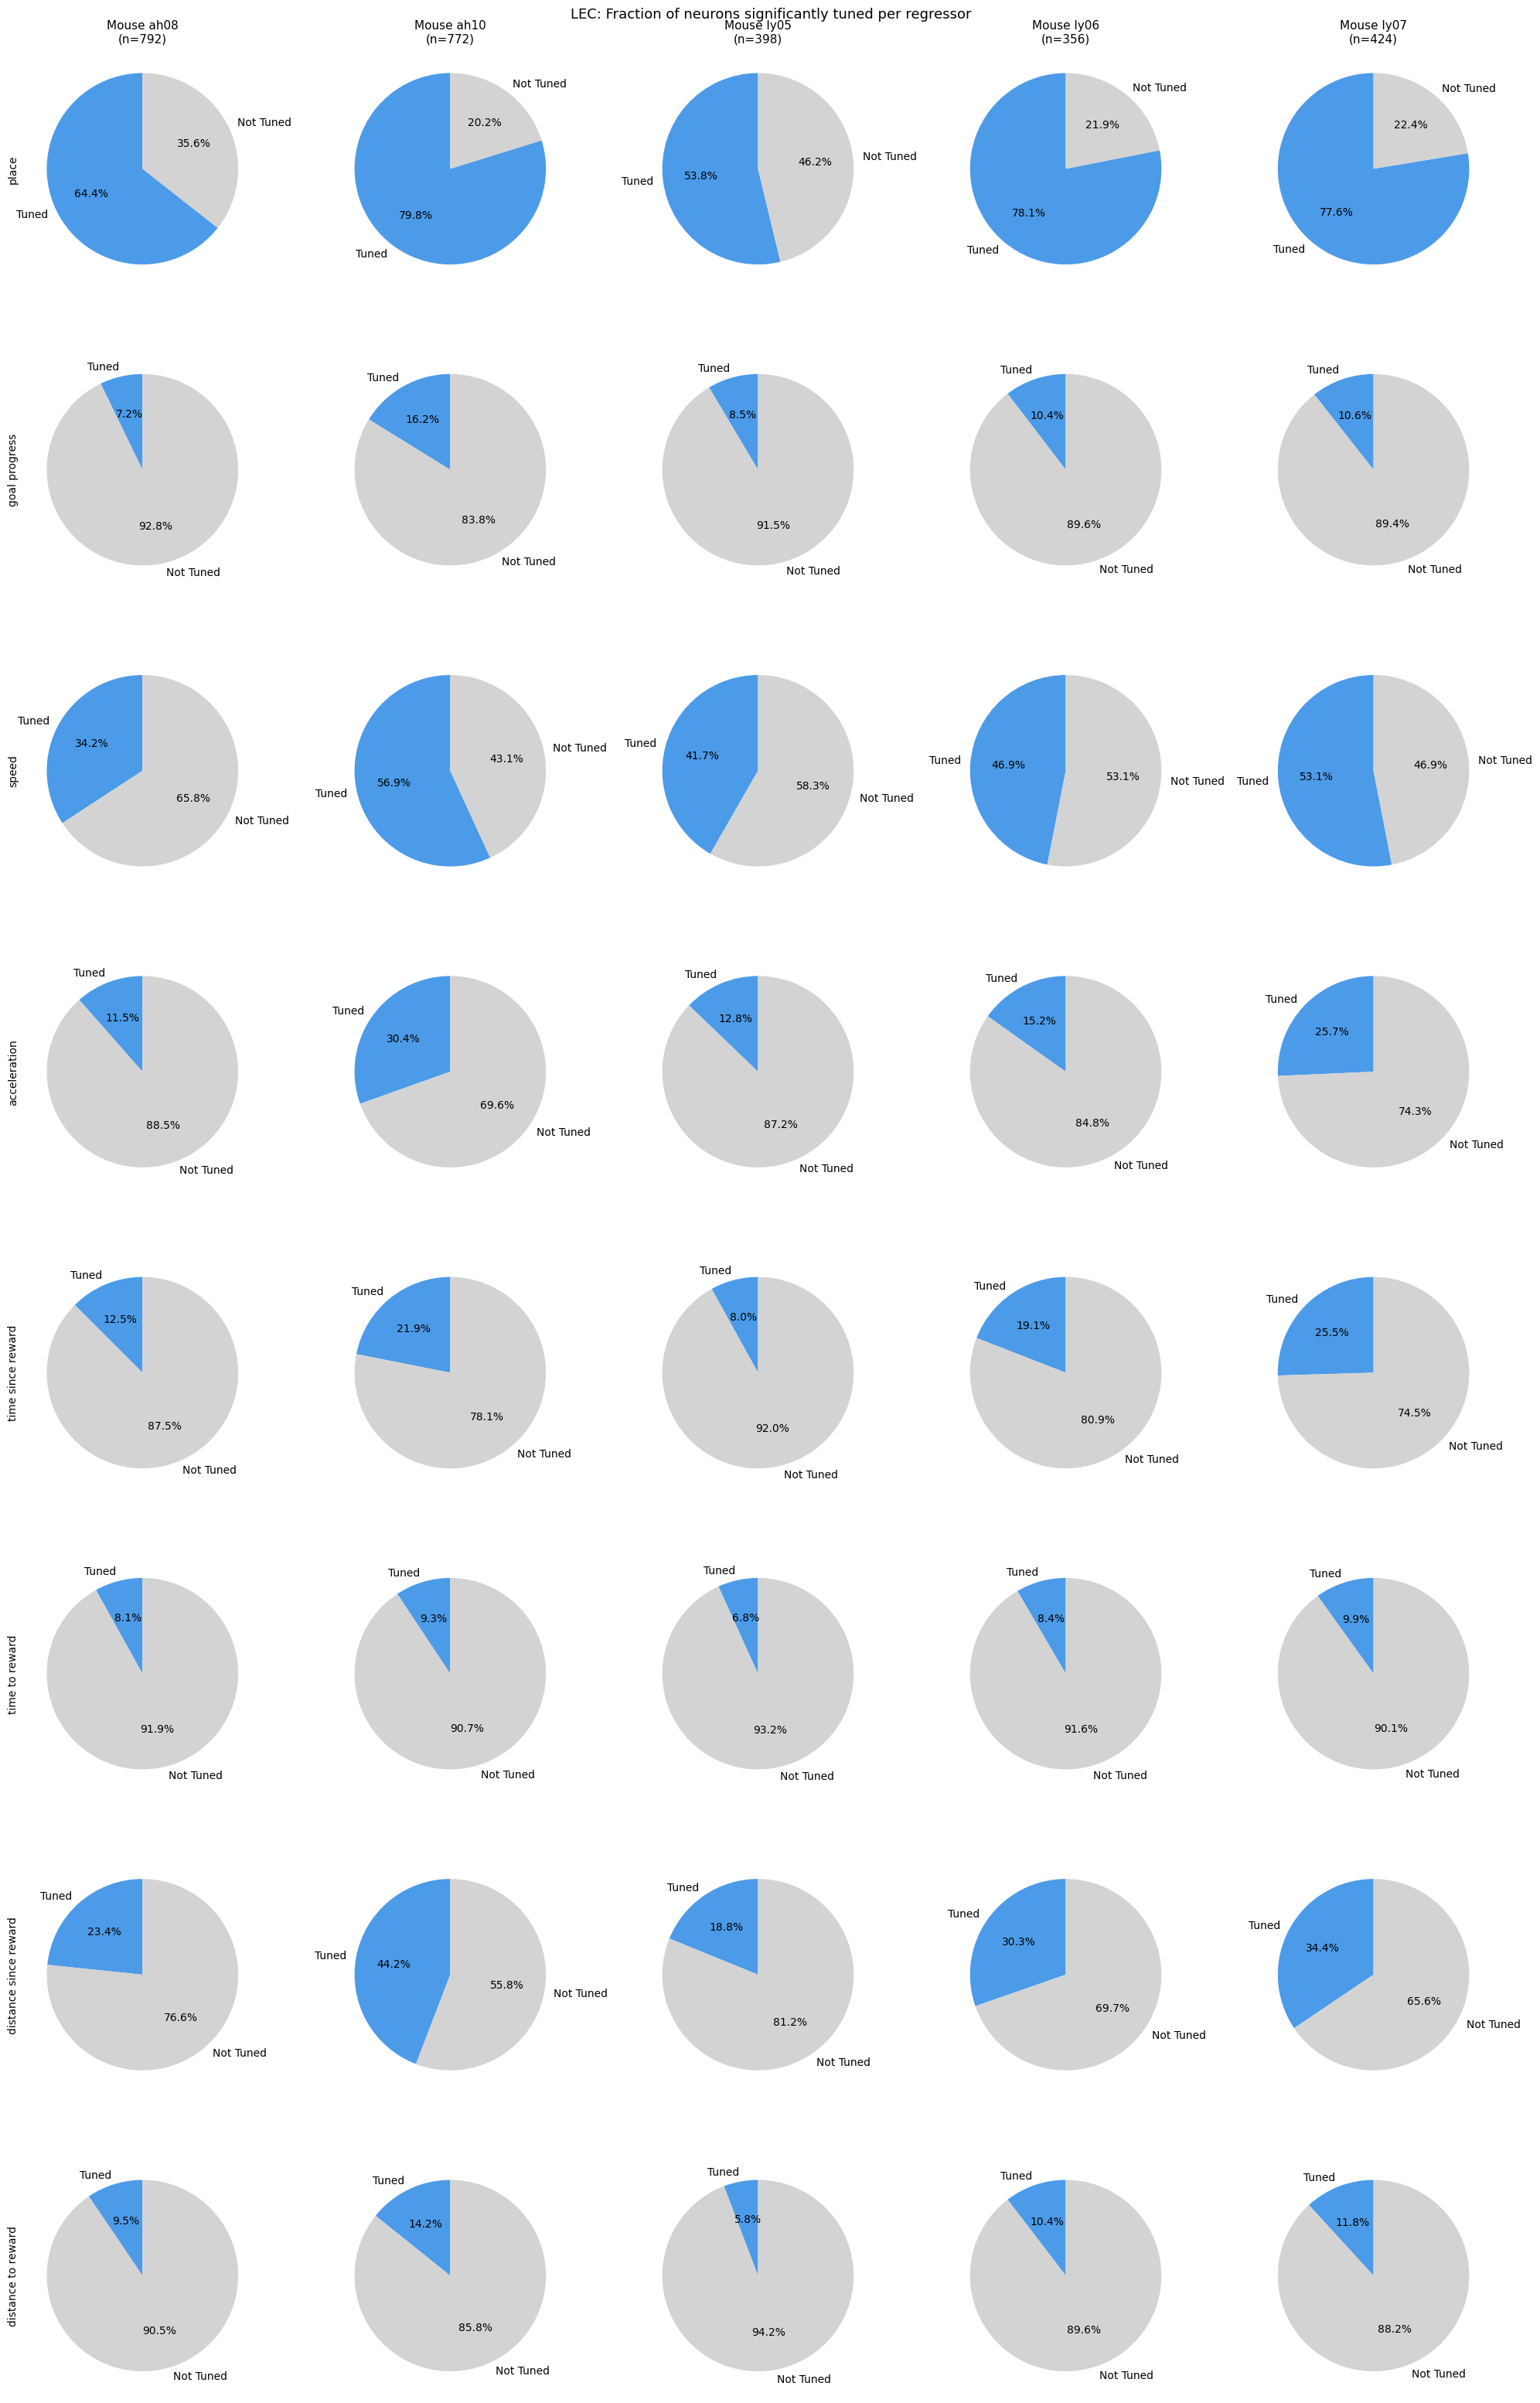

In [10]:
# 8 regressors (HD dropped) — matches the PFC fit.
LEC_NO_HD = ['place', 'goal_progress', 'speed', 'acceleration',
             'time_since_reward', 'time_to_reward',
             'distance_since_reward', 'distance_to_reward']

reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis, compute_tuning_arrays, group_tuning_by_mouse,
    plot_tuning_piecharts_binary,
)

GLM_results_noHD, Permutation_results_noHD = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=LEC_NO_HD,
)
tuned_dict_noHD = compute_tuning_arrays(
    GLM_results_noHD, Permutation_results_noHD,
    regressors_to_include=LEC_NO_HD,
)
mouse_tuning_concat_noHD = group_tuning_by_mouse(tuned_dict_noHD)
plot_tuning_piecharts_binary(mouse_tuning_concat_noHD,
                             regressors_to_include=LEC_NO_HD)

### Extended (CPD + joint `time_any`) — 8 regressors, matches PFC headline

Refits with `compute_cpd=True` and a joint `time_any` test so the time-vs-progress
CPD comparison is run on the exact same regressor set as PFC.

In [ ]:
from glm_analysis_v2 import plot_time_vs_progress_overlap, plot_cpd_time_vs_progress

GLM_results_noHD_ext, Permutation_results_noHD_ext, CPD_results_noHD_ext = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=LEC_NO_HD,
    compute_cpd=True,
    joint_drop_groups=[('time_any', ['time_since_reward', 'time_to_reward'])],
)
tuned_dict_noHD_ext = compute_tuning_arrays(
    GLM_results_noHD_ext, Permutation_results_noHD_ext,
    regressors_to_include=LEC_NO_HD,
)
mouse_tuning_concat_noHD_ext = group_tuning_by_mouse(tuned_dict_noHD_ext)
plot_tuning_piecharts_binary(mouse_tuning_concat_noHD_ext, regressors_to_include=LEC_NO_HD)
plot_time_vs_progress_overlap(mouse_tuning_concat_noHD_ext,
                              regressors_to_include=LEC_NO_HD, use_joint_time=False)
plot_cpd_time_vs_progress(CPD_results_noHD_ext, group_by_mouse=True)

# Per-mouse paired test on CPD difference (time_any - goal_progress)
from collections import defaultdict
by_mouse_diff = defaultdict(list)
for mr, neuron_dict in CPD_results_noHD_ext.items():
    mouse = mr.split('_')[0]
    for cpd in neuron_dict.values():
        g = cpd.get('goal_progress', np.nan)
        t = cpd.get('time_any', np.nan)
        if not (np.isnan(g) or np.isnan(t)):
            by_mouse_diff[mouse].append(t - g)
print('Per-mouse mean Δ (CPD_time_any − CPD_progress), LEC no-HD:')
for mouse in sorted(by_mouse_diff.keys()):
    diffs = np.array(by_mouse_diff[mouse])
    print(f'  {mouse}: μ={diffs.mean():+.5f}  n={len(diffs)}')

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   4%|▍         | 1/24 [52:05<19:58:04, 3125.41s/it]


ah08_20250616_20250617
  Design matrix: 12953 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:   8%|▊         | 2/24 [1:42:09<18:39:43, 3053.80s/it]

...


ah10_20250618_20250619
  Design matrix: 13335 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  33%|███▎      | 8/24 [7:15:06<15:01:51, 3381.99s/it]


ah10_20250620_20250623
  Design matrix: 16636 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)


Processing recording days:  38%|███▊      | 9/24 [8:20:17<14:46:48, 3547.24s/it]


ah10_20250624_20250625
  Design matrix: 15876 rows × 91 cols (regressors: ['place', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'], parameterization=all_bins)
